**PRACTICA DE MINERIA PREDICTIVA - CALIFORNIA HOUSING PRICES**

# Informacion del dataset:

California Housing Prices
Median house prices for California districts derived from the 1990 census.

1. longitude: A measure of how far west a house is; a higher value is farther west

2. latitude: A measure of how far north a house is; a higher value is farther north

3. housingMedianAge: Median age of a house within a block; a lower number is a newer building

4. totalRooms: Total number of rooms within a block

5. totalBedrooms: Total number of bedrooms within a block

6. population: Total number of people residing within a block

7. households: Total number of households, a group of people residing within a home unit, for a block

8. medianIncome: Median income for households within a block of houses (measured in tens of thousands of US Dollars)

9. medianHouseValue: Median house value for households within a block (measured in US Dollars)

10. oceanProximity: Location of the house w.r.t ocean/sea

# 1. Preparacion de los datos:



In [160]:
import pandas as pd
import numpy as np  # matrices y vectores
import matplotlib.pyplot as plt #gráfica

Este código importa `pandas` para datos, `numpy` para cálculos y
`matplotlib.pyplot` para gráficos.

In [161]:
data = pd.read_csv('housing.csv')
data.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.2300,37.8800,41.0000,880.0000,129.0000,322.0000,126.0000,8.3252,"452,600.0000",NEAR BAY
1,-122.2200,37.8600,21.0000,"7,099.0000","1,106.0000","2,401.0000","1,138.0000",8.3014,"358,500.0000",NEAR BAY
2,-122.2400,37.8500,52.0000,"1,467.0000",190.0000,496.0000,177.0000,7.2574,"352,100.0000",NEAR BAY
3,-122.2500,37.8500,52.0000,"1,274.0000",235.0000,558.0000,219.0000,5.6431,"341,300.0000",NEAR BAY
4,-122.2500,37.8500,52.0000,"1,627.0000",280.0000,565.0000,259.0000,3.8462,"342,200.0000",NEAR BAY


Carga el archivo `housing.csv` en un DataFrame llamado `data` y muestra las primeras 5 filas para una vista rápida de los datos.

In [162]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


`data.info()` da un resumen de las columnas: cuántos datos no nulos hay y el tipo de dato. Sirve para ver si faltan datos o si los tipos son correctos.

In [163]:
data['ocean_proximity']=data['ocean_proximity'].astype('category')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   longitude           20640 non-null  float64 
 1   latitude            20640 non-null  float64 
 2   housing_median_age  20640 non-null  float64 
 3   total_rooms         20640 non-null  float64 
 4   total_bedrooms      20433 non-null  float64 
 5   population          20640 non-null  float64 
 6   households          20640 non-null  float64 
 7   median_income       20640 non-null  float64 
 8   median_house_value  20640 non-null  float64 
 9   ocean_proximity     20640 non-null  category
dtypes: category(1), float64(9)
memory usage: 1.4 MB


Convierte la columna `ocean_proximity` a tipo categórico para optimizarla. `data.info()` confirma el cambio de tipo.

# **1.2. Eliminar variables irrelevantes y redundantes**

No existen formulas que demuestren la redundancia entre las variables.

# **1.3. Descripción estadística**

In [164]:
!pip install ydata-profiling

from ydata_profiling import ProfileReport

profile_data=ProfileReport(data, minimal=True)
profile_data

profile_data.to_file(output_file="output.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 10/10 [00:00<00:00, 63.64it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

Instala ydata-profiling y crea un informe detallado de los datos (guardado como output.html). Este informe ayuda a entender la calidad y características de los datos, como valores faltantes o atípicos.

El perfilado de los 20.640 registros y 10 variables muestra un conjunto en buen estado general: solo el 0,1% de las celdas está vacío y la ausencia se concentra por completo en total_bedrooms (207 casos, 1% de la columna), que es la única alerta que levanta el reporte. Lo más relevante aparece en la forma de las distribuciones: los cuatro agregados por bloque —total_rooms, total_bedrooms, population y households— tienen una asimetría fuerte a la derecha (curtosis de 22 a 74 y máximos de hasta 30 veces la mediana), lo que refleja diferencias de tamaño entre bloques censales más que anomalías del dato, y sugiere trabajarlos como ratios por hogar en lugar de valores absolutos. Las coordenadas confirman una cobertura restringida a California, y ocean_proximity está desbalanceada: <1H OCEAN e INLAND concentran el 76% de los registros mientras que ISLAND apenas suma 5 casos, insuficientes para sostenerla como categoría independiente. median_income y median_house_value son las variables con mayor variabilidad útil y, por su relación esperada, las candidatas naturales a estructurar el modelo.

# **1.4. Limpieza de datos atípicos-errores**



Existen datos atipicos pero por la naturaleza de los mismos preferimos conservarlos y no se aplica ningun metodo.

# **1.5. Limpieza de datos nulos: Imputación**

tenemos 'total_bedrooms' tiene 207 valores nulos (1%)

In [165]:
from sklearn.impute import SimpleImputer

var_numericas = ['total_bedrooms']
ImpNumeros = SimpleImputer(missing_values=np.nan, strategy='median')
data[var_numericas] = ImpNumeros.fit_transform(data[var_numericas])

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   longitude           20640 non-null  float64 
 1   latitude            20640 non-null  float64 
 2   housing_median_age  20640 non-null  float64 
 3   total_rooms         20640 non-null  float64 
 4   total_bedrooms      20640 non-null  float64 
 5   population          20640 non-null  float64 
 6   households          20640 non-null  float64 
 7   median_income       20640 non-null  float64 
 8   median_house_value  20640 non-null  float64 
 9   ocean_proximity     20640 non-null  category
dtypes: category(1), float64(9)
memory usage: 1.4 MB


Rellena los valores que faltan en total_bedrooms con la mediana de la columna. data.info() verifica que ya no hay valores nulos en esa columna.

In [166]:
#Valores de la imputación
print(ImpNumeros.statistics_)

[435.]


Este comando muestra el valor de la mediana (435.0) que se usó para rellenar los datos faltantes en total_bedrooms.

# **1.6. Correlaciones para redundancias**

In [167]:
data['ocean_proximity'].value_counts()

,count
ocean_proximity,
<1H OCEAN,9136
INLAND,6551
NEAR OCEAN,2658
NEAR BAY,2290
ISLAND,5


data['ocean_proximity'].value_counts() muestra cuántas veces aparece cada categoría en la columna ocean_proximity. Ayuda a ver la distribución de la proximidad al océano.

In [168]:
data_num = pd.get_dummies(data, drop_first=True, dtype = int)
data_num.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.2300,37.8800,41.0000,880.0000,129.0000,322.0000,126.0000,8.3252,"452,600.0000",0,0,1,0
1,-122.2200,37.8600,21.0000,"7,099.0000","1,106.0000","2,401.0000","1,138.0000",8.3014,"358,500.0000",0,0,1,0
2,-122.2400,37.8500,52.0000,"1,467.0000",190.0000,496.0000,177.0000,7.2574,"352,100.0000",0,0,1,0
3,-122.2500,37.8500,52.0000,"1,274.0000",235.0000,558.0000,219.0000,5.6431,"341,300.0000",0,0,1,0
4,-122.2500,37.8500,52.0000,"1,627.0000",280.0000,565.0000,259.0000,3.8462,"342,200.0000",0,0,1,0


Convierte las variables categóricas (como ocean_proximity) en columnas numéricas binarias (0 o 1) usando pd.get_dummies. data_num almacena este nuevo DataFrame y se muestran sus primeras filas.

In [169]:
#Correlaciones
correlaciones=data_num.corr()
correlaciones

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
longitude,1.0000,-0.9247,-0.1082,0.0446,0.0691,0.0998,0.0553,-0.0152,-0.0460,-0.0556,0.0094,-0.4745,0.0455
latitude,-0.9247,1.0000,0.0112,-0.0361,-0.0665,-0.1088,-0.0710,-0.0798,-0.1442,0.3512,-0.0166,0.3588,-0.1608
housing_median_age,-0.1082,0.0112,1.0000,-0.3613,-0.3190,-0.2962,-0.3029,-0.1190,0.1056,-0.2366,0.0170,0.2552,0.0216
total_rooms,0.0446,-0.0361,-0.3613,1.0000,0.9271,0.8571,0.9185,0.1980,0.1342,0.0256,-0.0076,-0.0230,-0.0092
total_bedrooms,0.0691,-0.0665,-0.3190,0.9271,1.0000,0.8735,0.9744,-0.0076,0.0495,-0.0062,-0.0043,-0.0197,0.0006
population,0.0998,-0.1088,-0.2962,0.8571,0.8735,1.0000,0.9072,0.0048,-0.0246,-0.0207,-0.0104,-0.0609,-0.0243
households,0.0553,-0.0710,-0.3029,0.9185,0.9744,0.9072,1.0000,0.0130,0.0658,-0.0394,-0.0091,-0.0101,0.0017
median_income,-0.0152,-0.0798,-0.1190,0.1980,-0.0076,0.0048,0.0130,1.0000,0.6881,-0.2375,-0.0092,0.0562,0.0273
median_house_value,-0.0460,-0.1442,0.1056,0.1342,0.0495,-0.0246,0.0658,0.6881,1.0000,-0.4849,0.0234,0.1603,0.1419
ocean_proximity_INLAND,-0.0556,0.3512,-0.2366,0.0256,-0.0062,-0.0207,-0.0394,-0.2375,-0.4849,1.0000,-0.0106,-0.2409,-0.2622


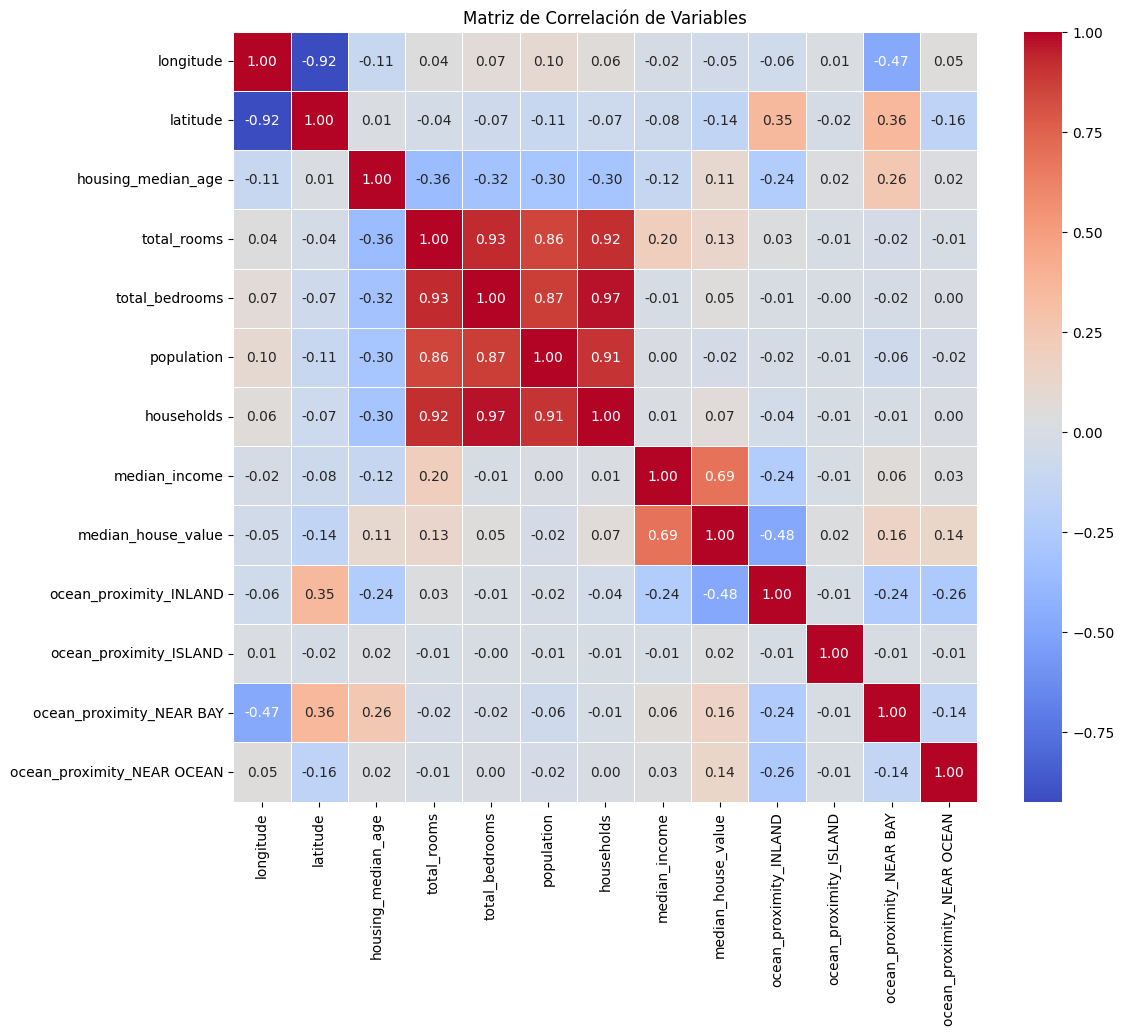

In [170]:
import seaborn as sns

plt.figure(figsize=(12, 10))
sns.heatmap(correlaciones, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Matriz de Correlación de Variables')
plt.show()

Calcula y muestra la correlación entre todas las variables numéricas en data_num. Esto indica cómo se relacionan entre sí: si aumentan o disminuyen juntas, o si no tienen relación lineal.

In [171]:
cor_variable_obj = correlaciones.loc['median_house_value']
cor_variable_obj

,median_house_value
longitude,-0.0460
latitude,-0.1442
housing_median_age,0.1056
total_rooms,0.1342
total_bedrooms,0.0495
population,-0.0246
households,0.0658
median_income,0.6881
median_house_value,1.0000
ocean_proximity_INLAND,-0.4849


El análisis de la matriz de correlación revela redundancia severa entre las variables que describen el tamaño del bloque censal. total_rooms y total_bedrooms presentan una correlación de 0,93, mientras que population y households alcanzan 0,91, valores que evidencian que cada par mide esencialmente la misma dimensión subyacente. Mantener ambas variables de cada par introduciría multicolinealidad en el modelo, inflando los errores estándar de los coeficientes y comprometiendo su interpretación. Por ello se conserva en cada caso la variable con mayor correlación con la variable objetivo median_house_value: se retiene total_rooms (0,134) frente a total_bedrooms (0,049), y households (0,066) frente a population (-0,025). La eliminación de total_bedrooms aporta un beneficio adicional, ya que era la única columna con datos faltantes del conjunto (207 registros, 1% de la columna), de modo que la depuración por redundancia resuelve simultáneamente el problema de valores ausentes. En contraste, la correlación de -0,92 entre longitude y latitude no se trata como redundancia, dado que responde a la orientación diagonal del territorio de California y no a duplicación de información: ambas coordenadas solo son interpretables de manera conjunta y su eliminación implicaría perder la dimensión geográfica, que resulta claramente relevante según lo indica la correlación de -0,485 entre ocean_proximity_INLAND y el precio de vivienda.

In [172]:
data_num = data_num.drop(columns=['total_bedrooms', 'population'])

In [173]:
data_num = data_num.drop(columns=['ocean_proximity_ISLAND'])

Finalmente se descarta la variable ocean_proximity_ISLAND, cuya correlación con median_house_value es de apenas 0,023, la más baja de todas las variables consideradas.

In [174]:
data_num.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   longitude                   20640 non-null  float64
 1   latitude                    20640 non-null  float64
 2   housing_median_age          20640 non-null  float64
 3   total_rooms                 20640 non-null  float64
 4   households                  20640 non-null  float64
 5   median_income               20640 non-null  float64
 6   median_house_value          20640 non-null  float64
 7   ocean_proximity_INLAND      20640 non-null  int64  
 8   ocean_proximity_NEAR BAY    20640 non-null  int64  
 9   ocean_proximity_NEAR OCEAN  20640 non-null  int64  
dtypes: float64(7), int64(3)
memory usage: 1.6 MB


# **2. Modelos de predccion**

# **2.1. División 70-30**





<Axes: >

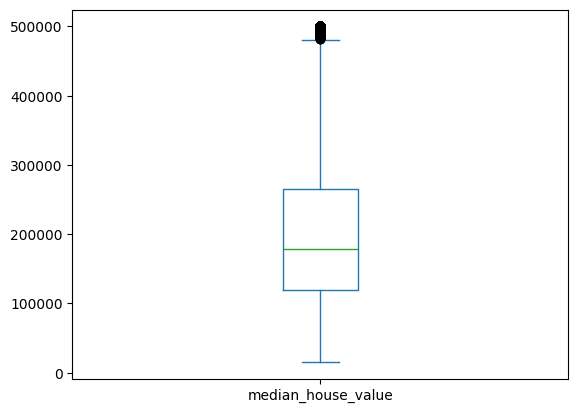

In [175]:
#División 70-30
from sklearn.model_selection import train_test_split
X = data_num.drop("median_house_value", axis = 1) # Variables predictoras
Y = data_num['median_house_value'] #Variable objetivo
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, stratify=None) # Es en none porque es de regresion
Y_train.plot(kind='box')


<Axes: ylabel='Frequency'>

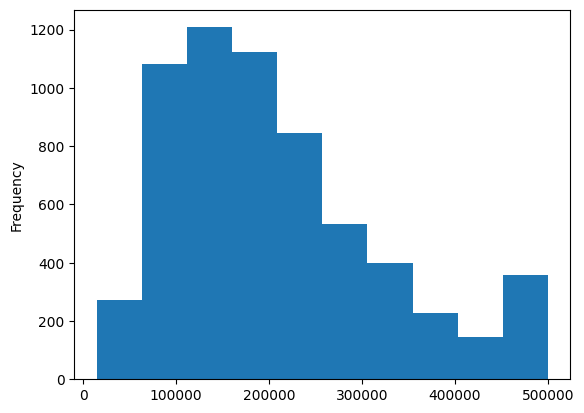

In [176]:
# Variable objetivo del 30% - hist
Y_test.plot(kind='hist')

In [177]:
#Dataframe para comparar los resultados
medidas= pd.DataFrame(index=['mse','rmse','mae','mape','max'])

# **2.2. Arbol de regresion**

In [178]:
#Creación del modelo con el conjunto de entrenamiento
from sklearn.tree import DecisionTreeRegressor
model_Tree = DecisionTreeRegressor(criterion='poisson', min_samples_leaf=2, max_depth=9)
model_Tree.fit(X_train, Y_train)#70% entrenamiento


DecisionTreeRegressor(criterion='poisson', max_depth=9, min_samples_leaf=2)

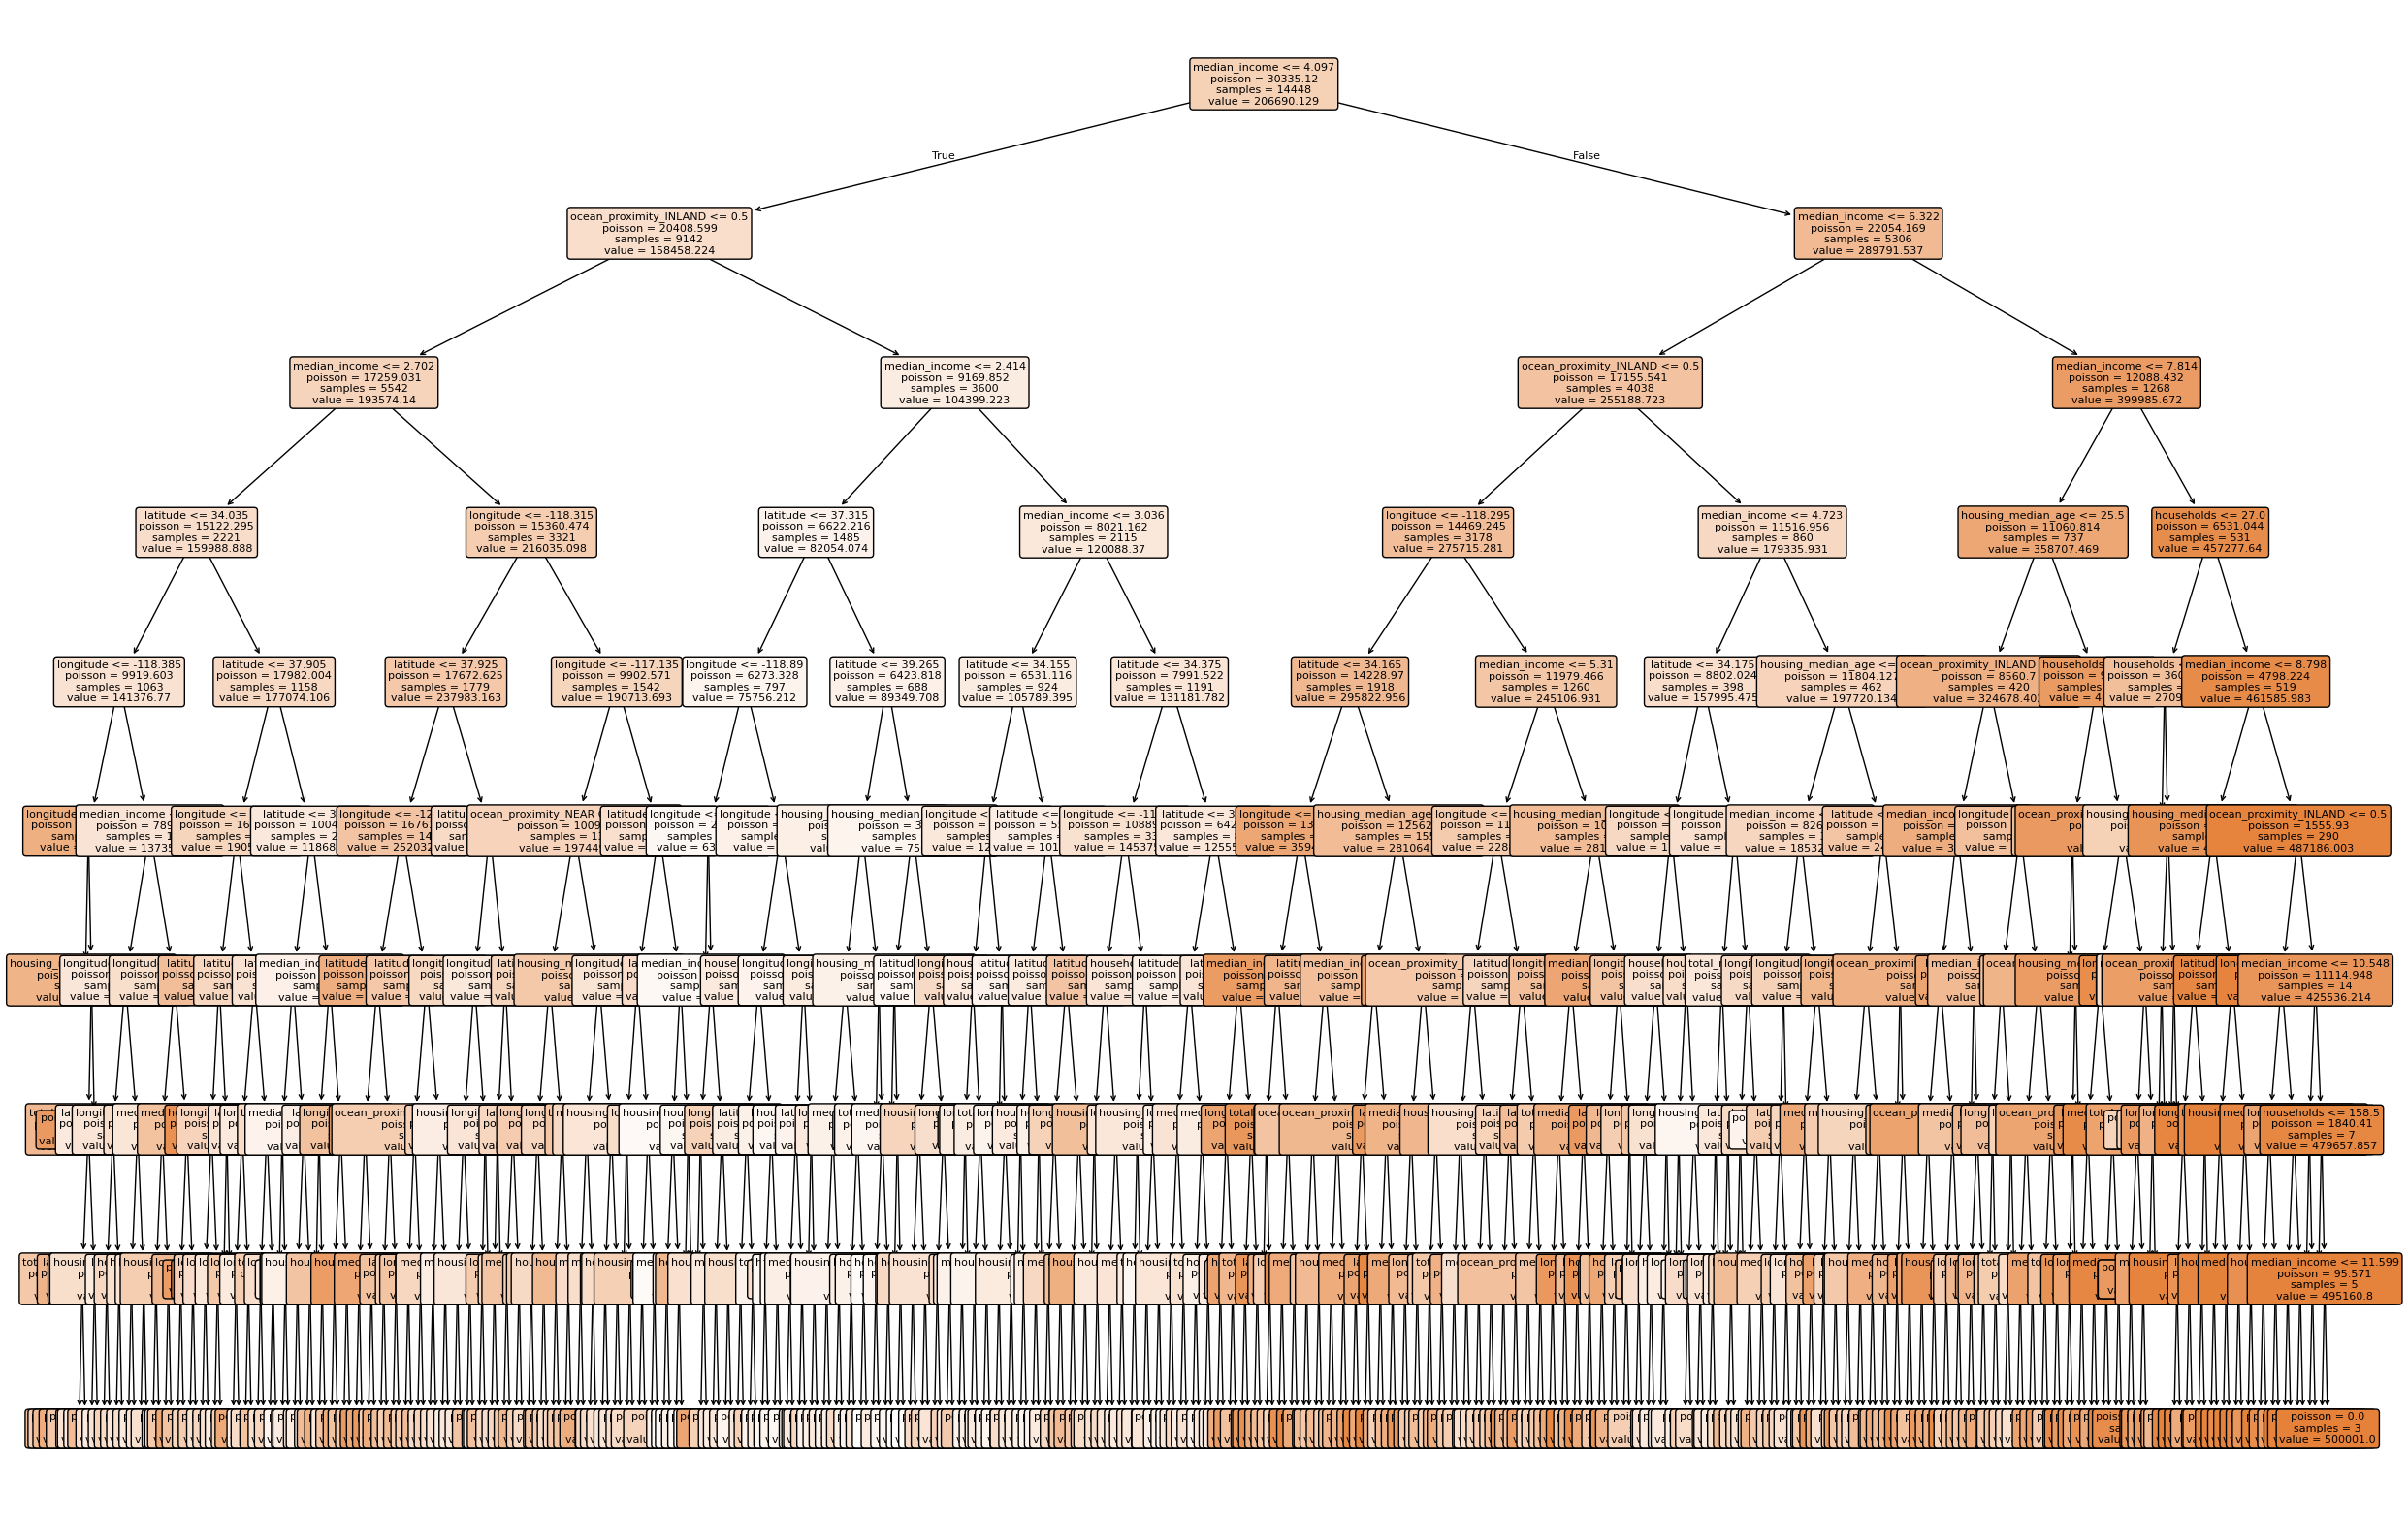

In [179]:
from sklearn.tree import plot_tree
plt.figure(figsize=(30,20)) #Tamaño de la imagen
plot_tree(model_Tree, feature_names=X_train.columns.values, rounded=True,  fontsize=8, filled=True)
plt.show()

In [180]:
#Evaluación del árbol 30%
from sklearn import metrics
Y_pred = model_Tree.predict(X_test) #30%

#Medidas de evaluación en regresión
mse = metrics.mean_squared_error(Y_test,Y_pred) #No es intepretable
rmse = np.sqrt(mse) #Si es intepretable
mae= metrics.mean_absolute_error(Y_test,Y_pred) #Si es intepretable
mape=metrics.mean_absolute_percentage_error(Y_test,Y_pred) #Verificar si la objetivo es 0
max=metrics.max_error(Y_test,Y_pred)
medidas['Arbol']=[mse, rmse, mae, mape,max]
medidas


,Arbol
mse,"3,459,648,596.3550"
rmse,"58,818.7776"
mae,"39,881.8458"
mape,0.2211
max,"392,465.8649"


# **2.3. Random Forest**

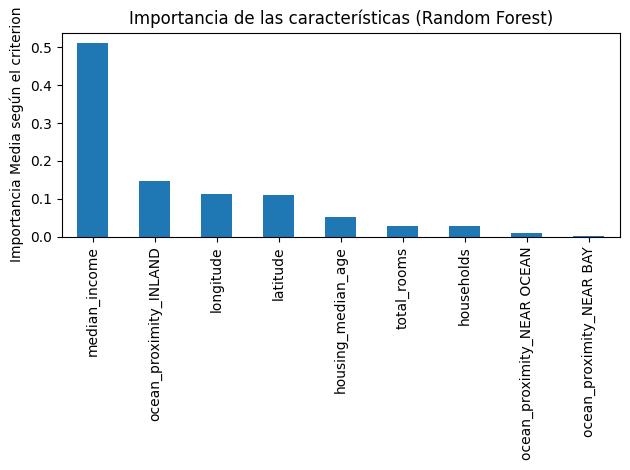

In [181]:
#Random Forest
from sklearn.ensemble import RandomForestRegressor

model_rf= RandomForestRegressor(n_estimators=150,  max_samples=0.9, criterion='squared_error',
                              max_depth=15, min_samples_leaf=2)
model_rf.fit(X_train, Y_train) #70%

importances = model_rf.feature_importances_
feature_names = X_train.columns
forest_importances = pd.Series(importances, index=feature_names)

fig, ax = plt.subplots()
forest_importances.sort_values(ascending=False).plot.bar(ax=ax)
ax.set_title("Importancia de las características (Random Forest)")
ax.set_ylabel("Importancia Media según el criterion")
fig.tight_layout()
plt.show()

                  Arbol                 RF
mse  3,459,648,596.3550 2,399,908,638.4719
rmse        58,818.7776        48,988.8624
mae         39,881.8458        32,415.1592
mape             0.2211             0.1820
max        392,465.8649       371,870.4300


/tmp/ipykernel_1552/582828784.py:17: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()],'k--', color = 'black', lw=2)


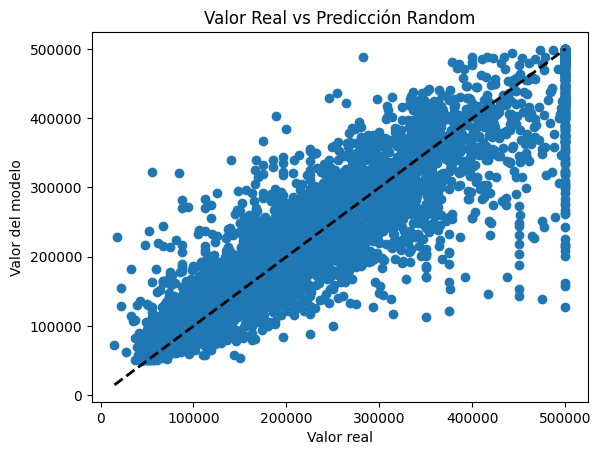

In [182]:
#Evaluación de Random
from sklearn import metrics

Y_pred = model_rf.predict(X_test) #30%

#Medidas de error
mse = metrics.mean_squared_error(Y_test,Y_pred)
rmse = np.sqrt(mse)
mae= metrics.mean_absolute_error(Y_test,Y_pred)
mape=metrics.mean_absolute_percentage_error(Y_test,Y_pred)
max=metrics.max_error(Y_test,Y_pred)
medidas['RF']=[mse, rmse, mae, mape,max]
print(medidas)

#Gráfica Valor Real vs Predicción
plt.scatter(Y_test, Y_pred)
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()],'k--', color = 'black', lw=2)
plt.xlabel('Valor real')
plt.ylabel('Valor del modelo')
plt.title('Valor Real vs Predicción Random')
plt.show()

# **2.4. Xgboost**

                  Arbol                 RF            XGBoost
mse  3,459,648,596.3550 2,399,908,638.4719 2,341,447,289.3317
rmse        58,818.7776        48,988.8624        48,388.5037
mae         39,881.8458        32,415.1592        31,976.0295
mape             0.2211             0.1820             0.1813
max        392,465.8649       371,870.4300       366,499.4141


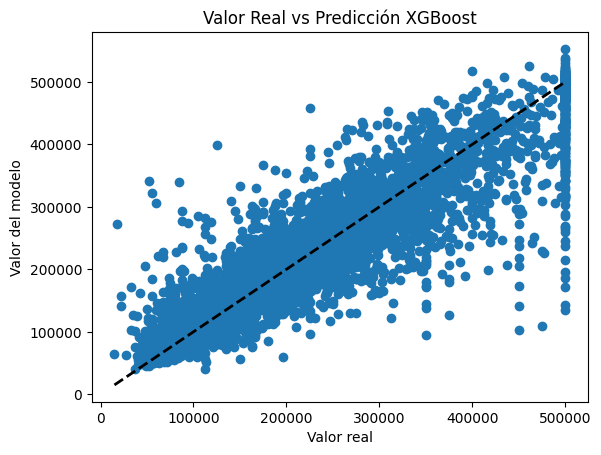

In [183]:
import xgboost as xgb
from sklearn import metrics
import numpy as np
import matplotlib.pyplot as plt

# Create an XGBoost Regressor model for regression

model_xgb = xgb.XGBRegressor(
    objective='reg:squarederror', # For regression with squared error
    eval_metric='rmse',         # Evaluation metric for regression (Root Mean Squared Error)
    n_estimators=150,           # Number of boosting rounds
    learning_rate=0.2,          # Step size shrinkage
    max_depth=12,               # Maximum depth of a tree
    subsample=0.8,              # Subsample ratio of the training instance
    colsample_bytree=0.8,       # Subsample ratio of columns when constructing each tree
    random_state=3,
    tree_method='hist'          # Faster tree construction for large datasets
)

# Entrenar el modelo (70%)
model_xgb.fit(X_train, Y_train)

# Predicciones del modelo (30%)
Y_pred_xgb = model_xgb.predict(X_test)


#Medidas de error
mse = metrics.mean_squared_error(Y_test,Y_pred_xgb)
rmse = np.sqrt(mse)
mae= metrics.mean_absolute_error(Y_test,Y_pred_xgb)
mape=metrics.mean_absolute_percentage_error(Y_test,Y_pred_xgb)
max_err=metrics.max_error(Y_test,Y_pred_xgb) # Renamed 'max' to 'max_err' to avoid conflict with built-in max()
medidas['XGBoost']=[mse, rmse, mae, mape,max_err] # Corrected column name to 'XGBoost'
print(medidas)

#Gráfica Valor Real vs Predicción
plt.scatter(Y_test, Y_pred_xgb)
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], color = 'black', linestyle='--', lw=2) # Fixed redundant color warning
plt.xlabel('Valor real')
plt.ylabel('Valor del modelo')
plt.title('Valor Real vs Predicción XGBoost') # Corrected plot title
plt.show()

# **2.5. KNN**

In [184]:
#Normalización de las variables numéricas (las dummies no se normalizan)
from sklearn.preprocessing import MinMaxScaler

min_max_scaler = MinMaxScaler()

variables_numericas = ['longitude', 'latitude', 'housing_median_age',
                       'total_rooms', 'households', 'median_income']

#Ajuste de los parámetros sobre el 100% de los datos: max - min
min_max_scaler.fit(data_num[variables_numericas])

#Se aplica la normalización a 80% y 20%
X_train[variables_numericas] = min_max_scaler.transform(X_train[variables_numericas])
X_test[variables_numericas]  = min_max_scaler.transform(X_test[variables_numericas])

X_train.head()

,longitude,latitude,housing_median_age,total_rooms,households,median_income,ocean_proximity_INLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
6576,0.6135,0.1785,0.6078,0.2702,0.2435,0.6442,0,0,0
7963,0.6135,0.1403,0.8039,0.0508,0.0654,0.2209,0,0,0
12611,0.2819,0.6366,0.5882,0.0785,0.0921,0.2613,1,0,0
5417,0.5896,0.1562,0.8235,0.0378,0.0405,0.3338,0,0,0
14215,0.7261,0.0138,0.5490,0.1029,0.1199,0.2449,0,0,1


                  Arbol                 RF            XGBoost  \
mse  3,459,648,596.3550 2,399,908,638.4719 2,341,447,289.3317   
rmse        58,818.7776        48,988.8624        48,388.5037   
mae         39,881.8458        32,415.1592        31,976.0295   
mape             0.2211             0.1820             0.1813   
max        392,465.8649       371,870.4300       366,499.4141   

                    Knn  
mse  3,993,502,976.2477  
rmse        63,194.1688  
mae         42,516.8339  
mape             0.2279  
max        396,761.0000  


/tmp/ipykernel_1552/3430831234.py:21: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()],'k--', color = 'black', lw=2)


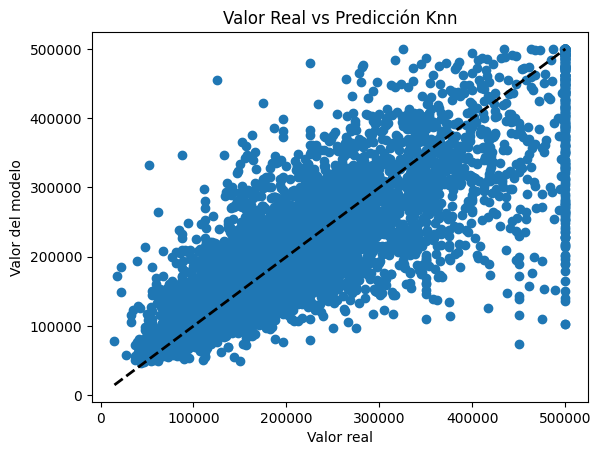

In [185]:
from sklearn.neighbors import  KNeighborsRegressor
model_Knn = KNeighborsRegressor(n_neighbors=5, metric='minkowski') #minkowski
model_Knn.fit(X_train, Y_train) #70%

#Evaluación de KNN
from sklearn import metrics

Y_pred = model_Knn.predict(X_test) #30%

#Medidas de error
mse = metrics.mean_squared_error(Y_test,Y_pred)
rmse = np.sqrt(mse)
mae= metrics.mean_absolute_error(Y_test,Y_pred)
mape=metrics.mean_absolute_percentage_error(Y_test,Y_pred)
max=metrics.max_error(Y_test,Y_pred)
medidas['Knn']=[mse, rmse, mae, mape,max]
print(medidas)

#Gráfica Valor Real vs Predicción
plt.scatter(Y_test, Y_pred)
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()],'k--', color = 'black', lw=2)
plt.xlabel('Valor real')
plt.ylabel('Valor del modelo')
plt.title('Valor Real vs Predicción Knn')
plt.show()


# **2.6. Neural Network**

                  Arbol                 RF            XGBoost  \
mse  3,459,648,596.3550 2,399,908,638.4719 2,341,447,289.3317   
rmse        58,818.7776        48,988.8624        48,388.5037   
mae         39,881.8458        32,415.1592        31,976.0295   
mape             0.2211             0.1820             0.1813   
max        392,465.8649       371,870.4300       366,499.4141   

                    Knn                 NN  
mse  3,993,502,976.2477  4648481564.739844  
rmse        63,194.1688        68,179.7739  
mae         42,516.8339        48,893.2724  
mape             0.2279             0.2747  
max        396,761.0000       432,349.3087  


/tmp/ipykernel_1552/1726910334.py:33: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()],'k--', color = 'black', lw=2)


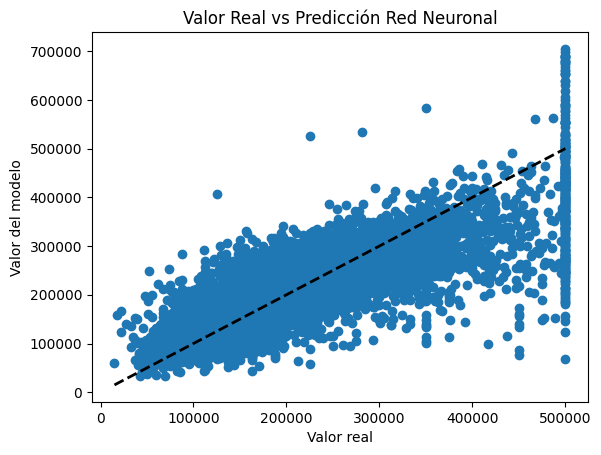

In [186]:
from sklearn.neural_network import MLPRegressor

#Solo se configura capas ocultas, no se configura capa de entrada y de salida
#activation -> función activación de la oculta: sigmoid, logistic, linear, relu
#hidden_layer_sizes=5,7 -> dos capas ocultas con 5 neuronas y 7 neuronas
#learning_rate-> tamaño del paso constante o decreciente (constant, adaptive)
#learning_rate_init-> valor tasa de aprendizaje
#momentum-> valor momentum
#max_iter-> iteaciones
#random_state-> semilla para generacion numeros seudoaletorios

model_NN = MLPRegressor(activation="relu",hidden_layer_sizes=(10), learning_rate='adaptive',
                     learning_rate_init=0.03, momentum= 0.02, max_iter=40000,  random_state=3)

model_NN.fit(X_train, Y_train) #70%

#Evaluación de NN
from sklearn import metrics

Y_pred = model_NN.predict(X_test) #30%

#Medidas de error
mse = metrics.mean_squared_error(Y_test,Y_pred)
rmse = np.sqrt(mse)
mae= metrics.mean_absolute_error(Y_test,Y_pred)
mape=metrics.mean_absolute_percentage_error(Y_test,Y_pred)
max=metrics.max_error(Y_test,Y_pred)
medidas['NN']=[format(mse), rmse, mae, mape,max]
print(medidas)

#Gráfica Valor Real vs Predicción
plt.scatter(Y_test, Y_pred)
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()],'k--', color = 'black', lw=2)
plt.xlabel('Valor real')
plt.ylabel('Valor del modelo')
plt.title('Valor Real vs Predicción Red Neuronal')
plt.show()


In [191]:
W1 = pd.DataFrame(model_NN.coefs_[0],
                  index=X_train.columns,
                  columns=[f'N{i+1}' for i in range(10)])
# Pesos capa oculta → salida  (10 × 1)
print('--- Pesos capa oculta → salida ---')
display(pd.DataFrame(model_NN.coefs_[1], index=W1.columns, columns=['salida']).round(4))
print('Sesgo de salida:', round(model_NN.intercepts_[1][0], 4))

--- Pesos capa oculta → salida ---


,salida
N1,"-1,185.5160"
N2,252.1458
N3,254.7431
N4,424.6785
N5,254.3803
N6,249.5952
N7,0.0000
N8,-0.0000
N9,385.6849
N10,324.4723


Sesgo de salida: 133.799


# **2.7. SMV**

In [187]:
#SVR
#Kernel='linear', 'poly', 'rbf', 'sigmoid', 'precomputed'

#SVR
#Kernel='linear', 'poly', 'rbf', 'sigmoid', 'precomputed'

#SVM
from sklearn.svm import SVR

modelSVM = SVR(kernel='poly', C=9) #'linear', 'poly'->degree, 'rbf', 'sigmoid', 'precomputed'
modelSVM.fit(X_train, Y_train) #70%

SVR(C=9, kernel='poly')

                  Arbol                 RF            XGBoost  \
mse  3,459,648,596.3550 2,399,908,638.4719 2,341,447,289.3317   
rmse        58,818.7776        48,988.8624        48,388.5037   
mae         39,881.8458        32,415.1592        31,976.0295   
mape             0.2211             0.1820             0.1813   
max        392,465.8649       371,870.4300       366,499.4141   

                    Knn                 NN                 SVM  
mse  3,993,502,976.2477  4648481564.739844  10383082332.845362  
rmse        63,194.1688        68,179.7739        101,897.4108  
mae         42,516.8339        48,893.2724         72,328.5022  
mape             0.2279             0.2747              0.3843  
max        396,761.0000       432,349.3087        373,936.2884  


/tmp/ipykernel_1552/1638901598.py:17: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()],'k--', color = 'black', lw=2)


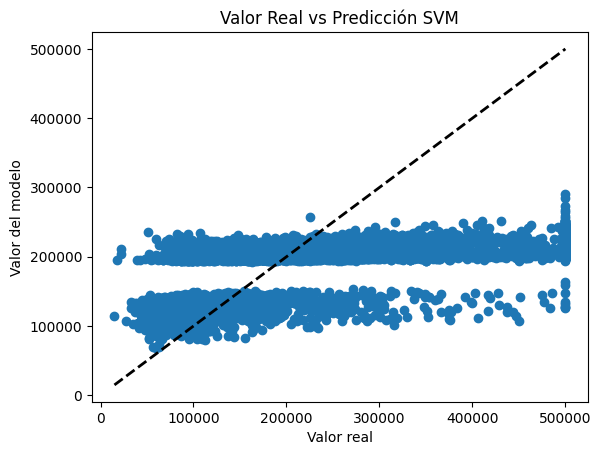

In [188]:
#Evaluación de SVM
from sklearn import metrics

Y_pred = modelSVM.predict(X_test) #30%

#Medidas de error
mse = metrics.mean_squared_error(Y_test,Y_pred)
rmse = np.sqrt(mse)
mae= metrics.mean_absolute_error(Y_test,Y_pred)
mape=metrics.mean_absolute_percentage_error(Y_test,Y_pred)
max=metrics.max_error(Y_test,Y_pred)
medidas['SVM']=[format(mse), rmse, mae, mape,max]
print(medidas)

#Gráfica Valor Real vs Predicción
plt.scatter(Y_test, Y_pred)
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()],'k--', color = 'black', lw=2)
plt.xlabel('Valor real')
plt.ylabel('Valor del modelo')
plt.title('Valor Real vs Predicción SVM')
plt.show()

# **3. Resultados**

In [189]:
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
medidas

,Arbol,RF,XGBoost,Knn,NN,SVM
mse,"3,459,648,596.3550","2,399,908,638.4719","2,341,447,289.3317","3,993,502,976.2477",4648481564.739844,10383082332.845362
rmse,"58,818.7776","48,988.8624","48,388.5037","63,194.1688","68,179.7739","101,897.4108"
mae,"39,881.8458","32,415.1592","31,976.0295","42,516.8339","48,893.2724","72,328.5022"
mape,0.2211,0.1820,0.1813,0.2279,0.2747,0.3843
max,"392,465.8649","371,870.4300","366,499.4141","396,761.0000","432,349.3087","373,936.2884"


Seleccionamos Random Forest por tener un muy buen resultado y ser relativamente liviano en compaaracion a xgboost

In [192]:
modelo_final=model_rf

In [193]:
modelo_final.fit(X, Y) #100%

RandomForestRegressor(max_depth=15, max_samples=0.9, min_samples_leaf=2,
                      n_estimators=150)

In [194]:
import pickle
filename = 'modelo-reg1.pkl'
variables=X.columns._values
pickle.dump([modelo_final, min_max_scaler,variables], open(filename, 'wb'))

# **PRÁCTICA 3: MINERÍA DE DATOS EN PYTHON**

A partir de esta sección se desarrollan los puntos A, B y C de la Práctica 3. Las secciones anteriores (preparación de los datos y primera comparación de modelos con una sola partición 70/30) se conservan como punto de partida.

El modelo guardado en la celda anterior corresponde al parcial. En el punto D (despliegue) se reemplazará por el modelo hiperparametrizado de la sección 6.

Para que los resultados sean reproducibles, todas las particiones, validaciones cruzadas y modelos de esta parte usan una semilla fija (`SEMILLA = 42`).

In [35]:
%matplotlib inline
import os
import time
import warnings
warnings.filterwarnings('ignore')
os.environ['PYTHONWARNINGS'] = 'ignore'   # también silencia los avisos de los procesos paralelos (n_jobs=-1)

from sklearn.model_selection import train_test_split, KFold, cross_validate, cross_val_score, validation_curve, GridSearchCV
from sklearn.feature_selection import mutual_info_regression
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.compose import TransformedTargetRegressor
from sklearn.dummy import DummyRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.svm import SVR
from sklearn import metrics
import xgboost as xgb

SEMILLA = 42

# Colores de las gráficas de esta parte
AZUL, NARANJA, GRIS = '#2a78d6', '#eb6834', '#52514e'
plt.rcParams.update({'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.grid': True, 'grid.color': '#e6e6e3', 'grid.linewidth': 0.8,
                     'axes.axisbelow': True})

# **4. Selección de factores (punto A)**

En el parcial la depuración de variables se hizo solo por **redundancia** (correlación entre predictoras). En esta sección se mide la **relevancia** de cada variable candidata frente a la variable objetivo `median_house_value`, con tres criterios complementarios, y la selección final se valida con validación cruzada.

## **4.1. Variables candidatas**

Además de las variables originales se construyen tres razones por hogar, tal como sugería el perfilado de la sección 1.3. Los totales por bloque (`total_rooms`, `population`, etc.) dependen sobre todo del tamaño del bloque censal; las razones, en cambio, describen cómo son las viviendas:

- `rooms_per_household` = total_rooms / households (cuartos por vivienda)
- `bedrooms_per_room` = total_bedrooms / total_rooms (proporción de dormitorios)
- `population_per_household` = population / households (personas por vivienda)

También se corrige el tratamiento de la categoría ISLAND. En el parcial se eliminó su columna dummy, pero eso no elimina la categoría: sus 5 registros quedan con todas las dummies en 0, es decir, codificados como `<1H OCEAN` (la categoría de referencia). Como 5 casos no permiten estimar un efecto propio, se reasignan a `NEAR OCEAN`, que es la categoría más parecida (son viviendas ubicadas en una isla frente a la costa).

In [36]:
data_fs = data.copy()
data_fs['ocean_proximity'] = data_fs['ocean_proximity'].astype(str).replace('ISLAND', 'NEAR OCEAN')

# Razones por hogar
data_fs['rooms_per_household'] = data_fs['total_rooms'] / data_fs['households']
data_fs['bedrooms_per_room'] = data_fs['total_bedrooms'] / data_fs['total_rooms']
data_fs['population_per_household'] = data_fs['population'] / data_fs['households']

data_fs = pd.get_dummies(data_fs, columns=['ocean_proximity'], drop_first=True, dtype=int)

X_cand = data_fs.drop(columns='median_house_value')   # 14 variables candidatas
Y_fs = data_fs['median_house_value']

# División 70-30 con semilla fija. El 30% de prueba NO se usa hasta la evaluación final (sección 6)
X_entreno, X_prueba, Y_entreno, Y_prueba = train_test_split(X_cand, Y_fs, test_size=0.3, random_state=SEMILLA)

print('Entrenamiento:', X_entreno.shape, ' Prueba:', X_prueba.shape)
print('Variables candidatas:', list(X_cand.columns))

Entrenamiento: (14448, 14)  Prueba: (6192, 14)
Variables candidatas: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'rooms_per_household', 'bedrooms_per_room', 'population_per_household', 'ocean_proximity_INLAND', 'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN']


La partición 70/30 se hace **antes** de analizar la relevancia, y todo el análisis de esta sección usa solo el 70% de entrenamiento. El 30% de prueba queda reservado para la evaluación final del modelo hiperparametrizado, de modo que ninguna decisión se toma mirando esos datos.

## **4.2. Relevancia de cada variable**

Se usan tres criterios, porque cada uno detecta cosas distintas:

1. **Correlación de Pearson y Spearman con el objetivo.** Mide relación lineal (Pearson) o monótona (Spearman). Es fácil de interpretar, pero no detecta relaciones no lineales ni interacciones: por ejemplo, la latitud y la longitud solo son informativas cuando se miran juntas.
2. **Información mutua** (`mutual_info_regression`). Mide cualquier tipo de dependencia entre la variable y el objetivo, también no lineal. Vale 0 si son independientes.
3. **Importancia por permutación** con un Random Forest. Mide cuánto empeora el R² de un modelo en datos de validación cuando se desordena al azar una variable. Es el criterio más cercano al aporte real dentro de un modelo, porque considera interacciones y descuenta la información que ya aportan otras variables. Se calcula sobre una porción de validación separada del 70% de entrenamiento.

In [37]:
# 1. Correlaciones con el objetivo
corr_pearson = X_entreno.corrwith(Y_entreno)
corr_spearman = X_entreno.corrwith(Y_entreno, method='spearman')

# 2. Información mutua
info_mutua = pd.Series(mutual_info_regression(X_entreno, Y_entreno, random_state=SEMILLA), index=X_entreno.columns)

# 3. Importancia por permutación (RF entrenado con 75% del entrenamiento, evaluado en el 25% restante)
X_a, X_v, Y_a, Y_v = train_test_split(X_entreno, Y_entreno, test_size=0.25, random_state=SEMILLA)
rf_sel = RandomForestRegressor(n_estimators=100, max_depth=15, min_samples_leaf=2, random_state=SEMILLA, n_jobs=-1)
rf_sel.fit(X_a, Y_a)
perm = permutation_importance(rf_sel, X_v, Y_v, n_repeats=5, scoring='r2', random_state=SEMILLA, n_jobs=-1)

relevancia = pd.DataFrame({
    'Pearson': corr_pearson,
    'Spearman': corr_spearman,
    'Info. mutua': info_mutua,
    'Permutación (caída R²)': perm.importances_mean,
    'Permutación (desv.)': perm.importances_std,
}).sort_values('Permutación (caída R²)', ascending=False)
relevancia.round(3)

,Pearson,Spearman,Info. mutua,Permutación (caída R²),Permutación (desv.)
median_income,0.6880,0.6770,0.3820,0.6760,0.0120
population_per_household,-0.0210,-0.2570,0.0750,0.1830,0.0050
ocean_proximity_INLAND,-0.4840,-0.5660,0.1900,0.1730,0.0070
latitude,-0.1420,-0.1640,0.3640,0.1390,0.0050
longitude,-0.0490,-0.0740,0.3840,0.1270,0.0010
housing_median_age,0.1070,0.0750,0.0340,0.0650,0.0030
rooms_per_household,0.1520,0.2560,0.0900,0.0150,0.0010
bedrooms_per_room,-0.2510,-0.3280,0.1520,0.0150,0.0010
total_rooms,0.1360,0.2050,0.0400,0.0020,0.0010
population,-0.0240,0.0050,0.0250,0.0010,0.0000


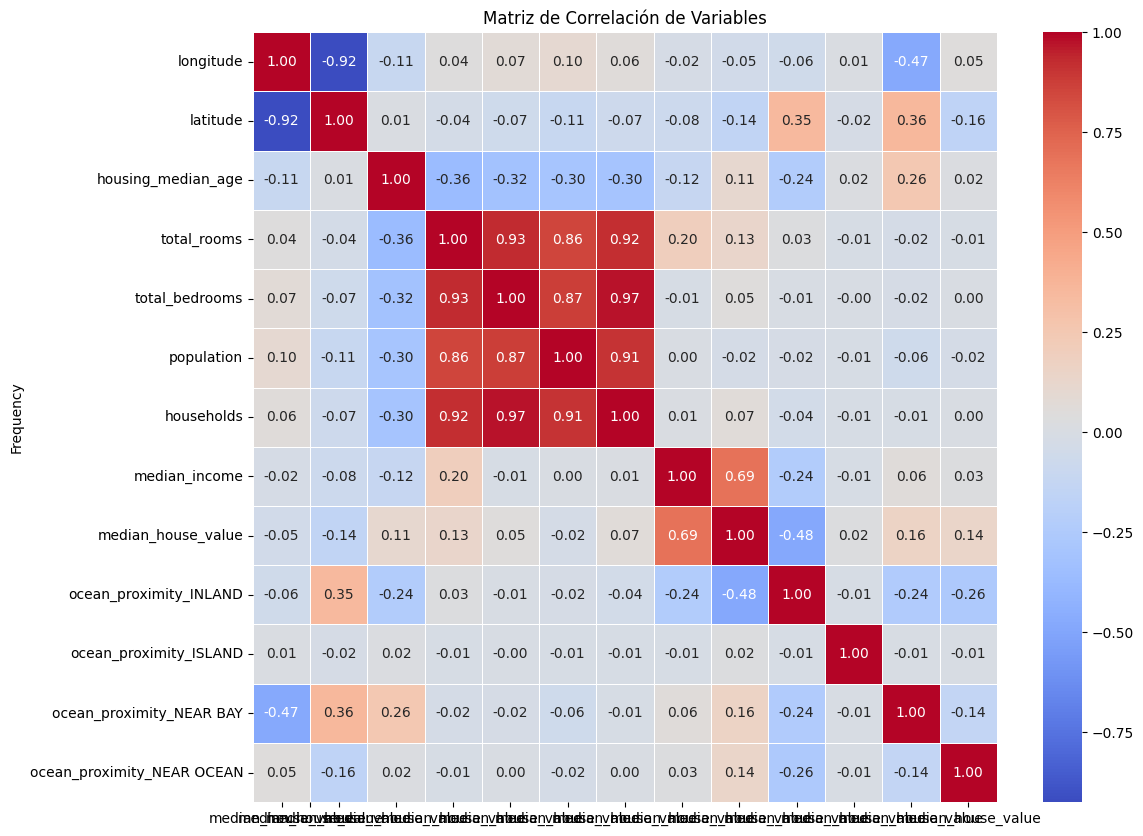

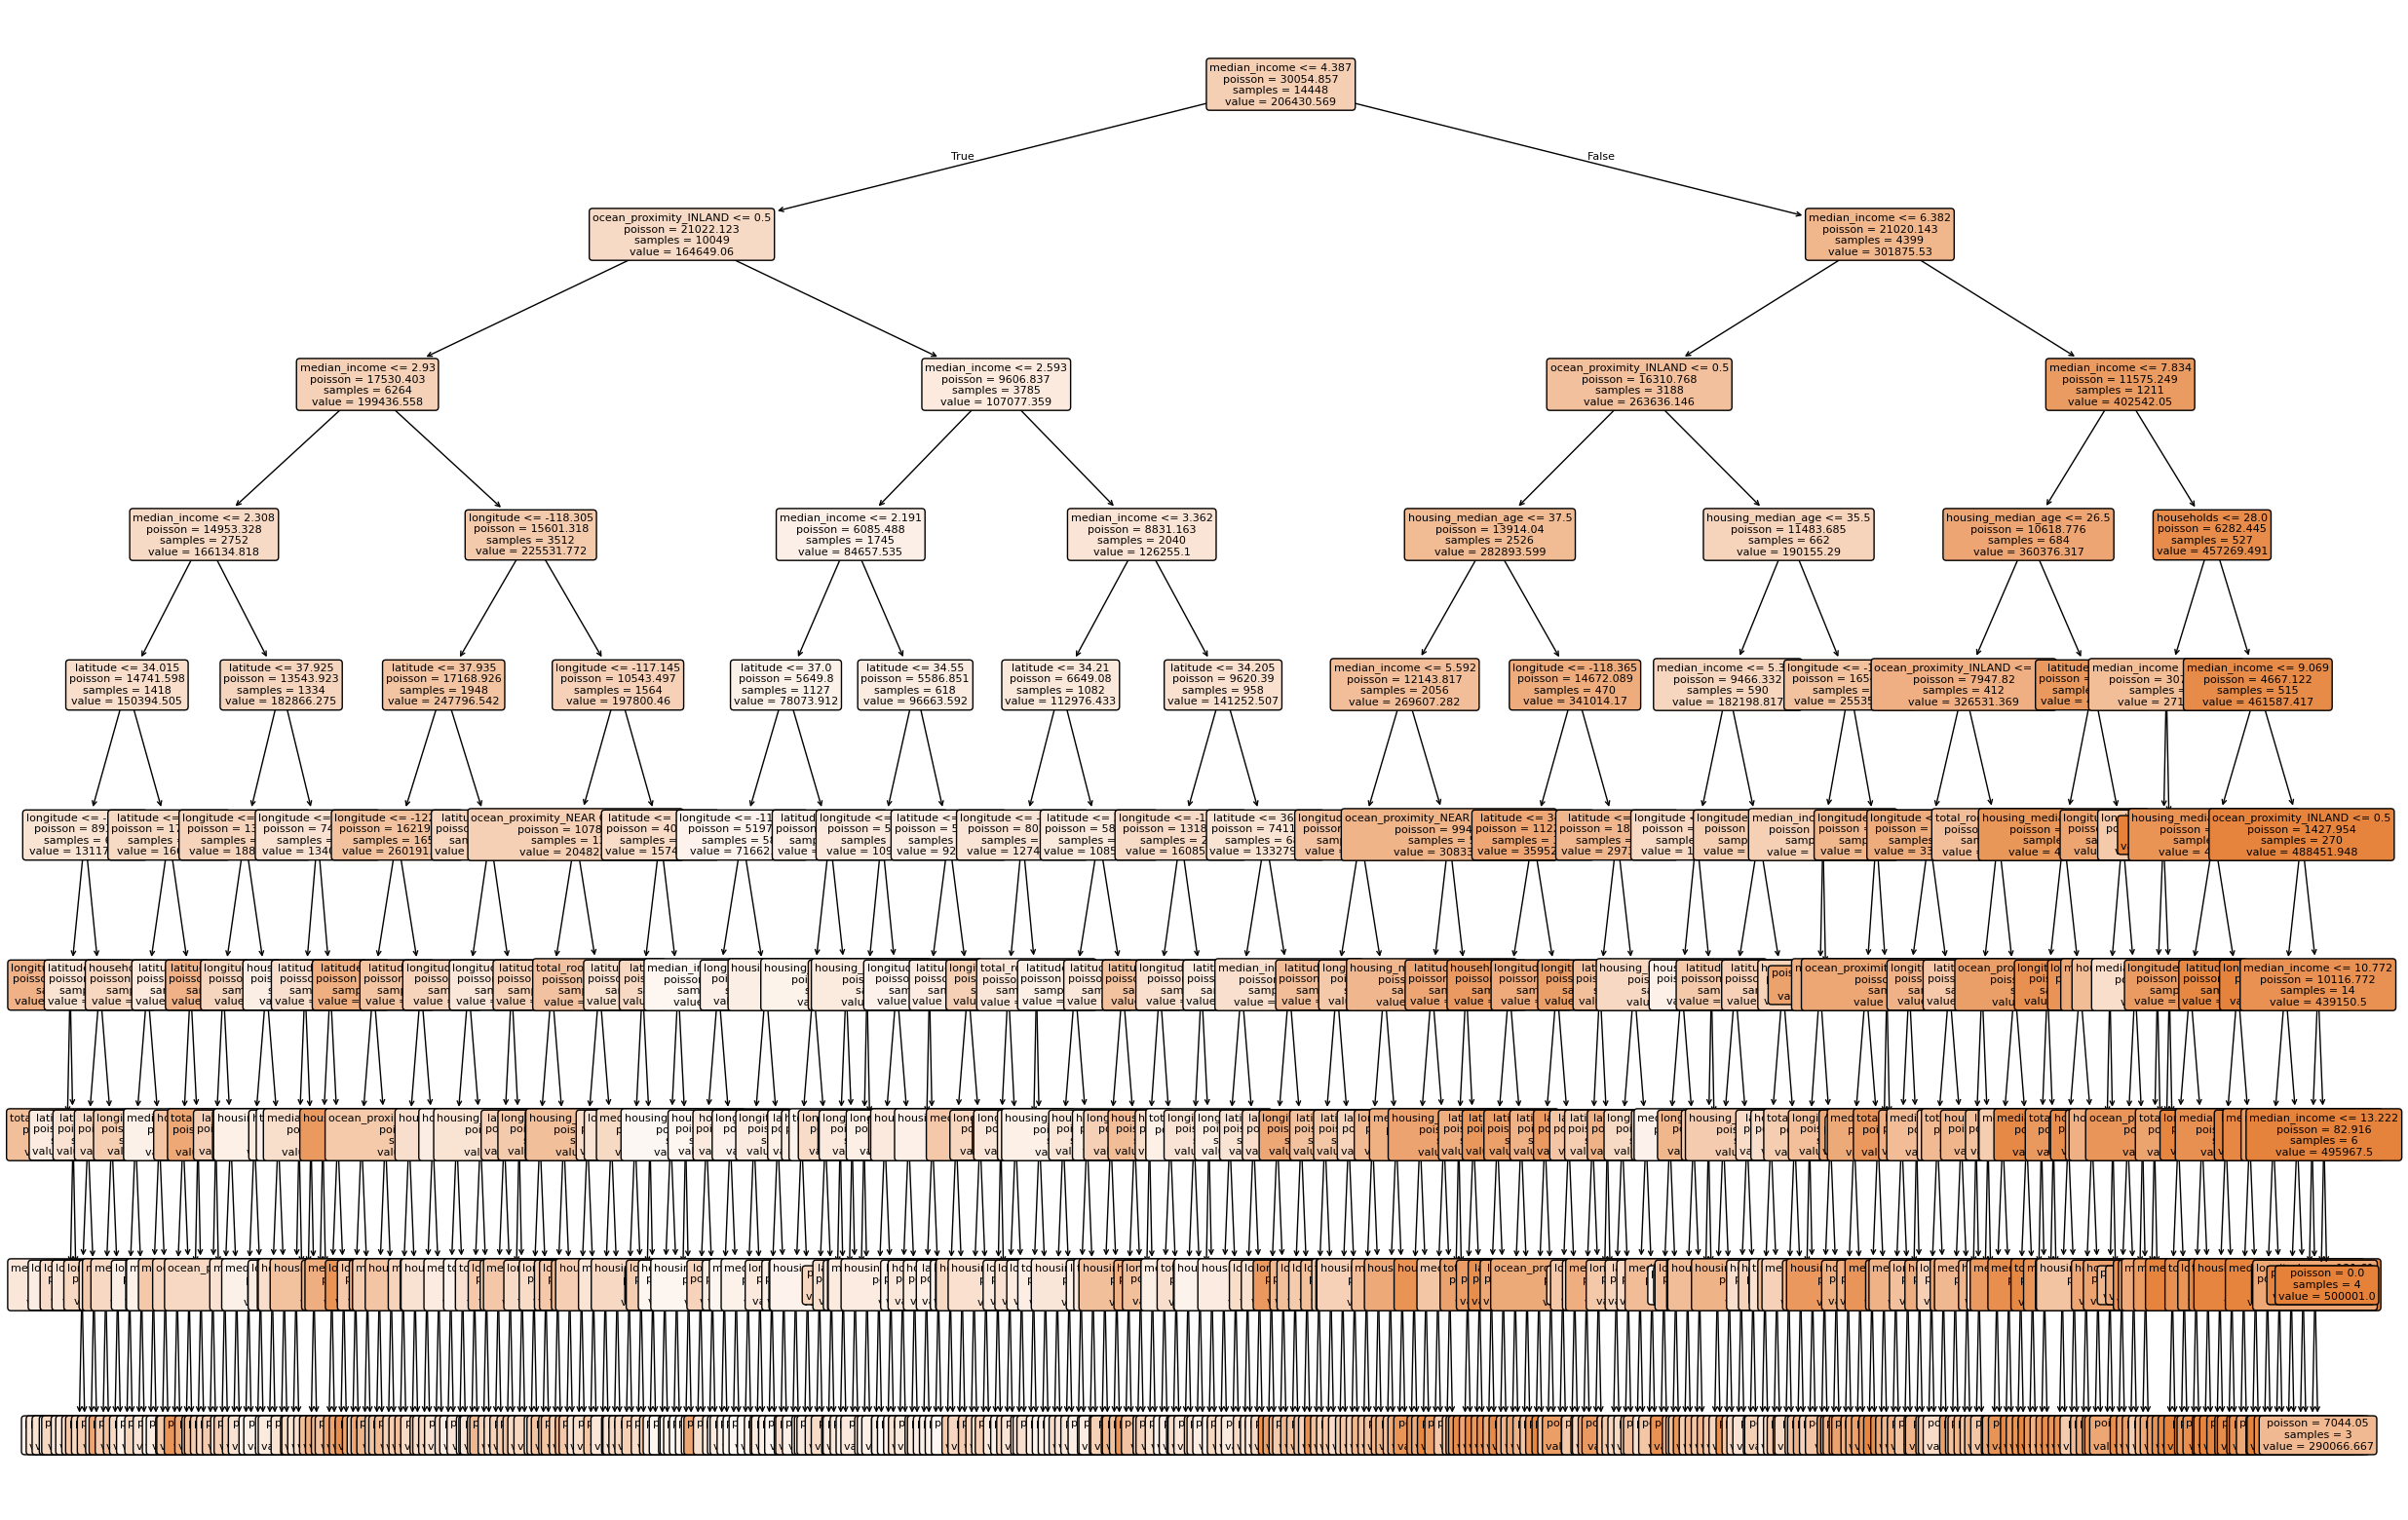

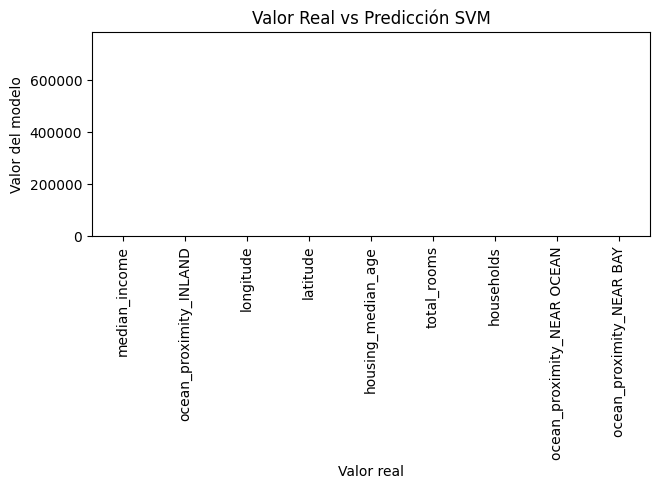

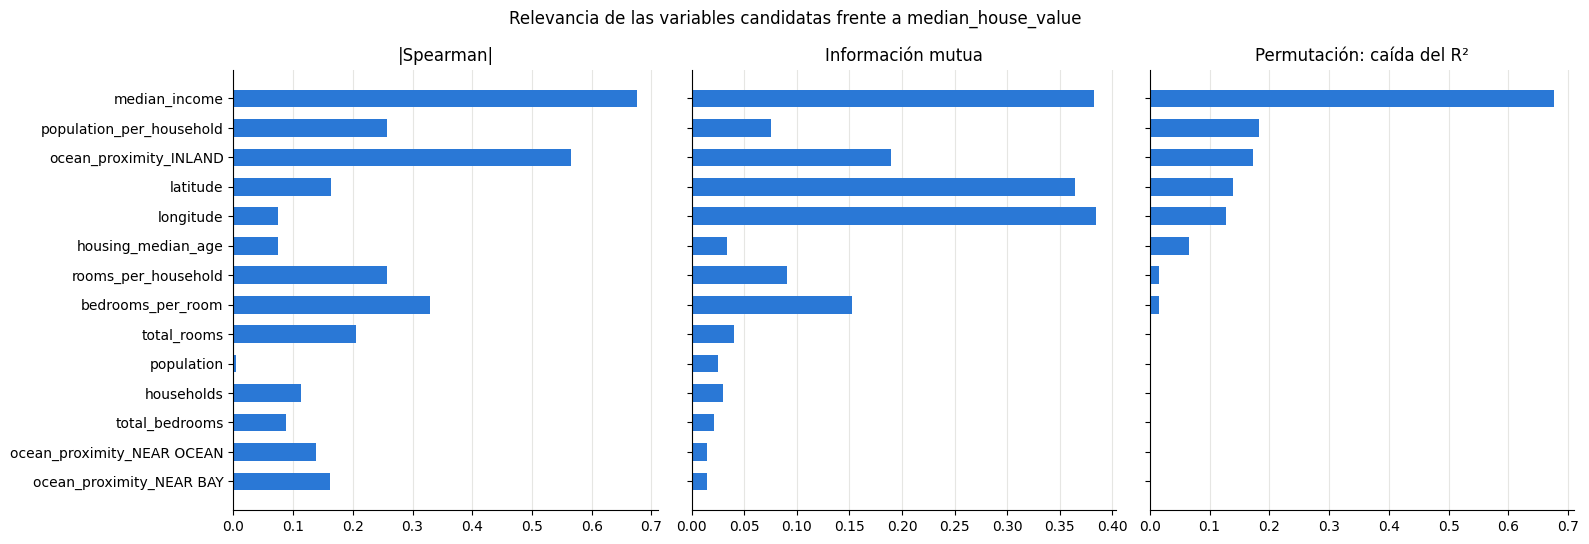

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5.5), sharey=True)
orden = relevancia.index[::-1]
medidas_rel = [('|Spearman|', relevancia['Spearman'].abs()),
               ('Información mutua', relevancia['Info. mutua']),
               ('Permutación: caída del R²', relevancia['Permutación (caída R²)'])]
for ax, (titulo, serie) in zip(axes, medidas_rel):
    ax.barh(orden, serie[orden], color=AZUL, height=0.6)
    ax.set_title(titulo)
    ax.grid(axis='y', visible=False)
fig.suptitle('Relevancia de las variables candidatas frente a median_house_value')
fig.tight_layout()
plt.show()

**Interpretación**

- **`median_income` es la variable más relevante en los tres criterios.** Tiene la mayor correlación con el precio (Spearman 0,68) y al permutarla el R² del modelo cae 0,68.
- **La ubicación es el segundo gran bloque de información, y la correlación no lo detecta.** La correlación de `latitude` y `longitude` con el precio es casi nula (Spearman -0,16 y -0,07), pero su información mutua es de las más altas (0,36 y 0,38) y al permutarlas el R² cae 0,14 y 0,13. Es el caso típico de una relación no lineal: el precio no sube de forma continua "hacia el norte" o "hacia el oeste", sino que depende de zonas concretas (la costa, las áreas metropolitanas). Si la selección se hubiera hecho solo con correlaciones, se habrían descartado dos de las variables más importantes.
- **`ocean_proximity_INLAND` confirma el efecto de la ubicación** (Spearman -0,57; caída de R² de 0,17). Las dummies `NEAR BAY` y `NEAR OCEAN` aportan poco de forma individual (caída de 0,001) porque su información ya está contenida en las coordenadas.
- **Las razones por hogar aportan más que las variables originales.** `population_per_household` es la segunda variable más importante para el modelo (caída de 0,18), aunque su correlación de Pearson es casi 0 (-0,02); en cambio, `population` y `households` por separado no aportan nada (caída de 0,001). `rooms_per_household` y `bedrooms_per_room` tienen un aporte pequeño (0,015 cada una).
- `housing_median_age` tiene un aporte moderado (caída de 0,065).
- **Los totales por bloque (`total_rooms`, `total_bedrooms`, `population`, `households`) son prácticamente irrelevantes** una vez están las razones (caída de 0,002 o menos). Esto confirma lo que sugería el perfilado: miden el tamaño del bloque censal, no cómo son las viviendas.

## **4.3. Validación de la selección**

La relevancia individual no basta para decidir: dos variables pueden ser relevantes y aportar la misma información. Por eso se comparan conjuntos completos de variables con validación cruzada de 5 particiones sobre el 70% de entrenamiento, usando XGBoost con la configuración del parcial:

- **Todas:** las 14 candidatas.
- **Parcial:** las 9 variables que se usaron en el parcial.
- **Selección propuesta:** ubicación, antigüedad, ingreso, personas por vivienda, cuartos por vivienda y las 3 dummies de `ocean_proximity` (9 variables).
- **Selección + bedrooms_per_room:** para comprobar si la proporción de dormitorios aporta algo adicional.

Las dummies de `ocean_proximity` se conservan o se descartan juntas, porque eliminar solo una de ellas no quita la categoría: la fusiona con la de referencia.

In [39]:
dummies_oceano = ['ocean_proximity_INLAND', 'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN']
seleccion = ['longitude', 'latitude', 'housing_median_age', 'median_income',
             'population_per_household', 'rooms_per_household'] + dummies_oceano

conjuntos = {
    'Todas': list(X_cand.columns),
    'Parcial': ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'households', 'median_income'] + dummies_oceano,
    'Selección propuesta': seleccion,
    'Selección + bedrooms_per_room': seleccion + ['bedrooms_per_room'],
}

kf = KFold(n_splits=5, shuffle=True, random_state=SEMILLA)
xgb_parcial = dict(objective='reg:squarederror', n_estimators=150, learning_rate=0.2, max_depth=12,
                   subsample=0.8, colsample_bytree=0.8, tree_method='hist', random_state=SEMILLA)

filas = []
for nombre, cols in conjuntos.items():
    rmse = -cross_val_score(xgb.XGBRegressor(**xgb_parcial), X_entreno[cols], Y_entreno,
                            cv=kf, scoring='neg_root_mean_squared_error')
    filas.append({'Conjunto': nombre, 'N° variables': len(cols),
                  'RMSE val. (media)': rmse.mean(), 'RMSE val. (desv.)': rmse.std()})
comparacion_conjuntos = pd.DataFrame(filas).set_index('Conjunto')
comparacion_conjuntos.round(0)

,N° variables,RMSE val. (media),RMSE val. (desv.)
Conjunto,,,
Todas,14,"49,525.0000","1,197.0000"
Parcial,9,"50,499.0000","1,121.0000"
Selección propuesta,9,"48,761.0000","1,303.0000"
Selección + bedrooms_per_room,10,"48,741.0000","1,165.0000"


**Conclusión de la selección de factores**

Se elige la **selección propuesta de 9 variables**: `longitude`, `latitude`, `housing_median_age`, `median_income`, `population_per_household`, `rooms_per_household` y las tres dummies de `ocean_proximity`.

- Tiene el menor error de validación junto con "Selección + bedrooms_per_room" (48.761 frente a 48.741 dólares). Esa diferencia de 20 dólares es insignificante frente a la variación entre particiones (unos 1.200 dólares), así que `bedrooms_per_room` no aporta y se prefiere el conjunto más simple.
- Mejora al conjunto del parcial (50.499) en unos 1.700 dólares con el mismo número de variables, y también a usar las 14 candidatas (49.525). La mejora es moderada, del orden de la variación entre particiones, pero coincide con el análisis de relevancia: cambiar los totales por bloque por razones por hogar sí aporta información.
- Usar más variables no da un mejor modelo: las 14 candidatas tienen más error que la selección.
- Quedan fuera `total_bedrooms` y `bedrooms_per_room`, las únicas que dependían de la columna con valores imputados, así que la imputación de la sección 1.5 ya no influye en el modelo.
- Para el despliegue, el usuario solo tendrá que ingresar datos sencillos del sector (ubicación, antigüedad, ingreso, número de cuartos, población, hogares y proximidad al océano). Las razones se calcularán internamente.

In [40]:
variables_finales = seleccion
X_entreno_sel = X_entreno[variables_finales]
X_prueba_sel = X_prueba[variables_finales]
print(len(variables_finales), 'variables finales:', variables_finales)

9 variables finales: ['longitude', 'latitude', 'housing_median_age', 'median_income', 'population_per_household', 'rooms_per_household', 'ocean_proximity_INLAND', 'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN']


# **5. Modelos predictivos con validación cruzada (punto B)**

## **5.1. Objetivo del modelo**

El objetivo es **estimar el valor mediano de las viviendas (`median_house_value`, en dólares) de un distrito censal de California** a partir de su ubicación, la antigüedad de las construcciones, el ingreso de los hogares y las características de las viviendas. Es un problema de **regresión supervisada**.

Un modelo así sirve como estimación de referencia del valor de un sector, por ejemplo para un análisis preliminar del mercado inmobiliario o para detectar zonas cuyo precio se aleja de lo esperado según sus características.

**Métricas de evaluación**

- **RMSE** (raíz del error cuadrático medio): métrica principal. Está en dólares y penaliza más los errores grandes.
- **MAE** (error absoluto medio): error típico en dólares, menos sensible a errores extremos.
- **MAPE**: error relativo promedio. Es válido aquí porque el objetivo nunca es 0.
- **R²**: proporción de la variabilidad del precio que explica el modelo (1 es perfecto; 0 equivale a predecir siempre la media).

## **5.2. Esquema de validación y revisión de overfitting y underfitting**

Se usa **validación cruzada K-fold con 5 particiones** sobre el 70% de entrenamiento: cada modelo se entrena 5 veces con 4/5 de los datos y se evalúa con el 1/5 restante, y se reporta la media y la desviación de las 5 evaluaciones. Esto da una estimación más confiable que una sola partición, que depende de qué registros cayeron en cada lado.

Con `return_train_score=True` también se obtiene el desempeño en los mismos datos con los que se entrenó. Comparar ambos permite diagnosticar:

- **Overfitting (sobreajuste):** muy buen desempeño en entrenamiento y claramente peor en validación. El modelo memoriza en lugar de generalizar.
- **Underfitting (subajuste):** desempeño pobre tanto en entrenamiento como en validación, con poca diferencia entre ambos. El modelo es demasiado simple o está mal configurado para capturar la relación.
- **Buen ajuste:** buen desempeño en validación y una brecha moderada frente al entrenamiento.

**Escalado.** KNN, la red neuronal y el SVM dependen de distancias o de gradientes, así que sus variables se normalizan con `MinMaxScaler` ajustado **solo con el 70% de entrenamiento** (en el parcial se ajustó con el 100%, lo que filtraba información del conjunto de prueba). Los modelos de árboles no necesitan escalado. Como el escalador se ajusta antes de la validación cruzada y no dentro de cada partición, queda una fuga mínima entre particiones; con MinMax solo influye en el mínimo y el máximo de cada variable, así que su efecto es despreciable.

In [41]:
variables_a_escalar = ['longitude', 'latitude', 'housing_median_age', 'median_income',
                       'population_per_household', 'rooms_per_household']

escalador = MinMaxScaler()
escalador.fit(X_entreno_sel[variables_a_escalar])   # solo con el 70% de entrenamiento

X_entreno_esc = X_entreno_sel.copy()
X_prueba_esc = X_prueba_sel.copy()
X_entreno_esc[variables_a_escalar] = escalador.transform(X_entreno_sel[variables_a_escalar])
X_prueba_esc[variables_a_escalar] = escalador.transform(X_prueba_sel[variables_a_escalar])

metricas_cv = {'rmse': 'neg_root_mean_squared_error', 'mae': 'neg_mean_absolute_error',
               'mape': 'neg_mean_absolute_percentage_error', 'r2': 'r2'}

def evaluar_cv(modelo, X):
    # Validación cruzada de 5 particiones con métricas de entrenamiento y validación
    r = cross_validate(modelo, X, Y_entreno, cv=kf, scoring=metricas_cv,
                       return_train_score=True, n_jobs=-1)
    return {
        'RMSE train': -r['train_rmse'].mean(),
        'RMSE val': -r['test_rmse'].mean(),
        'RMSE val desv.': r['test_rmse'].std(),
        'MAE val': -r['test_mae'].mean(),
        'MAPE val': -r['test_mape'].mean(),
        'R² train': r['train_r2'].mean(),
        'R² val': r['test_r2'].mean(),
        'Brecha R²': r['train_r2'].mean() - r['test_r2'].mean(),
        'Tiempo (s)': r['fit_time'].mean(),
    }

## **5.3. Configuración de las técnicas**

| Modelo | Configuración | Justificación |
|---|---|---|
| Línea base | Predice siempre la media del entrenamiento | Referencia mínima: cualquier modelo útil debe superarla |
| Árbol de regresión | `criterion='poisson'`, `max_depth=9`, `min_samples_leaf=2` | Configuración del parcial. La profundidad limitada evita que el árbol crezca hasta memorizar |
| Random Forest | 150 árboles, `max_depth=15`, `min_samples_leaf=2`, `max_samples=0.9` | Configuración del parcial. Promedia muchos árboles entrenados con muestras distintas para reducir la varianza |
| XGBoost | 150 rondas, `learning_rate=0.2`, `max_depth=12`, `subsample=0.8`, `colsample_bytree=0.8` | Configuración del parcial. Cada árbol corrige los errores de los anteriores (boosting) |
| KNN | `k=5`, distancia Minkowski (euclidiana), variables escaladas | Configuración del parcial. Predice con el promedio de los 5 distritos más parecidos |
| Red neuronal (parcial) | 1 capa oculta de 10 neuronas, `relu`, `learning_rate_init=0.03`, objetivo sin escalar, máximo 500 iteraciones | Se conserva para mostrar el efecto de no escalar el objetivo. En el parcial tenía 40.000 iteraciones; con el objetivo sin escalar la red necesita miles de iteraciones y la validación cruzada tardaba más de 10 minutos, por eso se limita a 500 |
| Red neuronal (ajustada) | Capas ocultas (64, 32), `relu`, `adam`, `early_stopping=True`, objetivo estandarizado | Más capacidad para relaciones no lineales; la parada temprana corta el entrenamiento cuando la validación interna deja de mejorar |
| SVM (parcial) | `kernel='poly'`, `C=9`, objetivo sin escalar | Se conserva para mostrar el efecto de no escalar el objetivo |
| SVM (ajustada) | `kernel='rbf'`, `C=10`, objetivo estandarizado | El kernel RBF modela fronteras suaves no lineales y es el punto de partida estándar para SVR |

**Por qué se escala el objetivo en la red neuronal y el SVM.** El precio va de unos 15.000 a 500.000 dólares. Con valores de esa magnitud, la red neuronal necesita pesos enormes y su entrenamiento por gradiente se vuelve inestable. En el SVM, los hiperparámetros `C` y `epsilon` están pensados para una escala cercana a 1: con `C=9` sobre precios de cientos de miles, el modelo casi no puede ajustarse. `TransformedTargetRegressor` estandariza el objetivo antes de entrenar y devuelve las predicciones a dólares, así que las métricas siguen siendo comparables. (El parámetro `momentum` del parcial no tenía efecto, porque solo se usa con el optimizador `sgd` y el que se usaba era `adam`.)

In [42]:
xgb_parcial_cv = dict(xgb_parcial, n_jobs=1)

modelos_cv = {
    'Línea base': (DummyRegressor(strategy='mean'), X_entreno_sel),
    'Árbol': (DecisionTreeRegressor(criterion='poisson', max_depth=9, min_samples_leaf=2, random_state=SEMILLA), X_entreno_sel),
    'Random Forest': (RandomForestRegressor(n_estimators=150, max_depth=15, min_samples_leaf=2, max_samples=0.9,
                                            random_state=SEMILLA, n_jobs=1), X_entreno_sel),
    'XGBoost': (xgb.XGBRegressor(**xgb_parcial_cv), X_entreno_sel),
    'KNN': (KNeighborsRegressor(n_neighbors=5, metric='minkowski'), X_entreno_esc),
    'Red neuronal (parcial)': (MLPRegressor(activation='relu', hidden_layer_sizes=(10,), learning_rate='adaptive',
                                            learning_rate_init=0.03, momentum=0.02, max_iter=500,
                                            random_state=SEMILLA), X_entreno_esc),   # 500 iteraciones: ver nota en 5.3
    'Red neuronal (ajustada)': (TransformedTargetRegressor(
                                    regressor=MLPRegressor(activation='relu', hidden_layer_sizes=(64, 32),
                                                           early_stopping=True, max_iter=500, random_state=SEMILLA),
                                    transformer=StandardScaler()), X_entreno_esc),
    'SVM (parcial)': (SVR(kernel='poly', C=9), X_entreno_esc),
    'SVM (ajustada)': (TransformedTargetRegressor(regressor=SVR(kernel='rbf', C=10),
                                                  transformer=StandardScaler()), X_entreno_esc),
}

resultados_cv = {}
for nombre, (modelo, X_modelo) in modelos_cv.items():
    inicio = time.time()
    resultados_cv[nombre] = evaluar_cv(modelo, X_modelo)
    print(f'{nombre:<25} listo en {time.time() - inicio:6.1f} s')

resultados_cv = pd.DataFrame(resultados_cv).T

Línea base                listo en    0.0 s


Árbol                     listo en    0.2 s


Random Forest             listo en   22.7 s


XGBoost                   listo en    6.2 s


KNN                       listo en    0.7 s


Red neuronal (parcial)    listo en   17.9 s


Red neuronal (ajustada)   listo en   14.7 s


SVM (parcial)             listo en   18.0 s


SVM (ajustada)            listo en   25.2 s


## **5.4. Resultados de la validación cruzada**

In [43]:
tabla_cv = resultados_cv.sort_values('RMSE val').copy()
formatos = {'RMSE train': '{:,.0f}', 'RMSE val': '{:,.0f}', 'RMSE val desv.': '{:,.0f}', 'MAE val': '{:,.0f}',
            'MAPE val': '{:.1%}', 'R² train': '{:.3f}', 'R² val': '{:.3f}', 'Brecha R²': '{:.3f}', 'Tiempo (s)': '{:.1f}'}
tabla_cv.style.format(formatos)

,RMSE train,RMSE val,RMSE val desv.,MAE val,MAPE val,R² train,R² val,Brecha R²,Tiempo (s)
XGBoost,"1,026","48,761","1,303","31,804",17.5%,1.000,0.822,0.178,2.0
Random Forest,"29,105","50,603","1,363","33,049",18.1%,0.937,0.808,0.128,7.3
Árbol,"49,508","61,356","1,353","41,060",22.4%,0.817,0.718,0.099,0.1
Red neuronal (ajustada),"60,112","61,955","3,442","42,334",23.2%,0.730,0.712,0.018,5.2
KNN,"51,244","63,839","1,598","42,729",22.8%,0.804,0.695,0.109,0.0
SVM (ajustada),"64,367","64,971","1,652","43,176",22.1%,0.691,0.684,0.007,4.5
Red neuronal (parcial),"73,182","73,203","1,582","53,347",30.0%,0.600,0.599,0.001,6.0
SVM (parcial),"104,989","105,016","1,715","74,628",39.7%,0.177,0.176,0.001,3.6
Línea base,"115,744","115,737","1,707","91,429",62.1%,0.000,-0.000,0.000,0.0


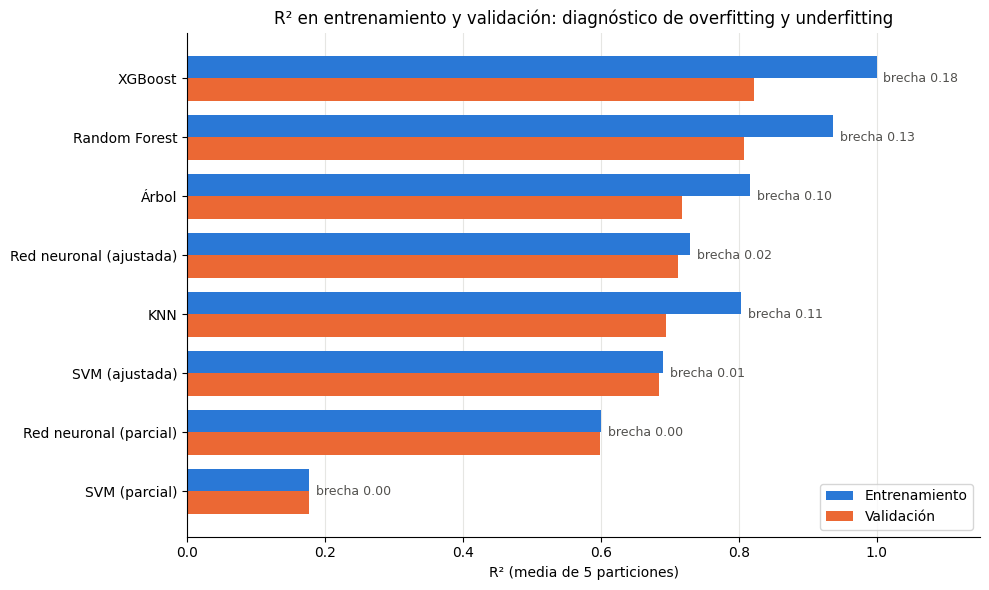

In [44]:
tabla_graf = tabla_cv.drop(index='Línea base').sort_values('R² val')
pos = np.arange(len(tabla_graf))
alto = 0.38

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(pos + alto/2, tabla_graf['R² train'], height=alto, color=AZUL, label='Entrenamiento')
ax.barh(pos - alto/2, tabla_graf['R² val'], height=alto, color=NARANJA, label='Validación')
for i, (tr, va) in enumerate(zip(tabla_graf['R² train'], tabla_graf['R² val'])):
    ax.text(np.maximum(tr, va) + 0.01, i, f'brecha {tr - va:.2f}', va='center', fontsize=9, color=GRIS)
ax.set_yticks(pos)
ax.set_yticklabels(tabla_graf.index)
ax.set_xlim(0, 1.15)
ax.set_xlabel('R² (media de 5 particiones)')
ax.set_title('R² en entrenamiento y validación: diagnóstico de overfitting y underfitting')
ax.grid(axis='y', visible=False)
ax.legend(loc='lower right')
fig.tight_layout()
plt.show()

## **5.5. Curva de validación: de underfitting a overfitting**

Para ver la transición entre ambos extremos se varía la profundidad máxima del árbol de regresión y se mide el error en entrenamiento y en validación para cada valor. Un árbol muy poco profundo es demasiado simple (underfitting); uno muy profundo memoriza los datos de entrenamiento (overfitting).

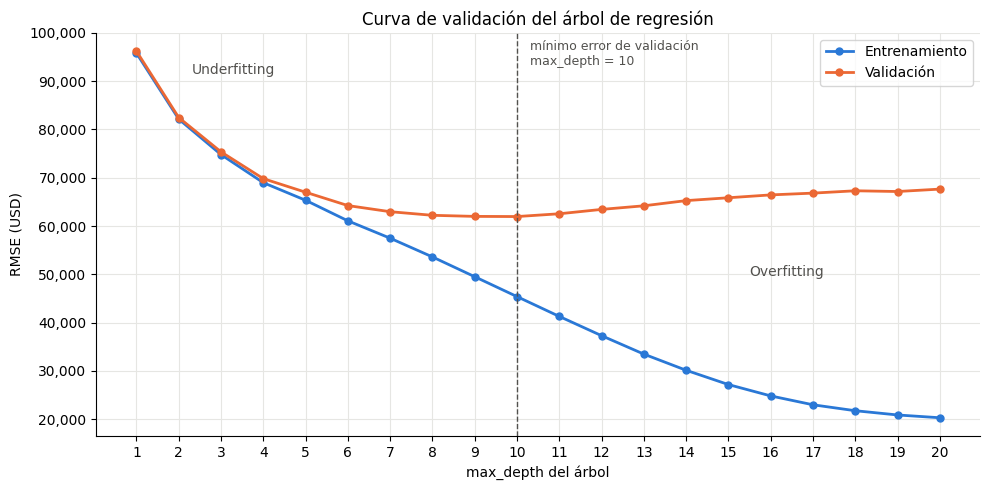

Mejor profundidad: 10  |  RMSE validación: 61,968  |  RMSE entrenamiento: 45,395


In [45]:
profundidades = np.arange(1, 21)
train_sc, val_sc = validation_curve(
    DecisionTreeRegressor(min_samples_leaf=2, random_state=SEMILLA), X_entreno_sel, Y_entreno,
    param_name='max_depth', param_range=profundidades, cv=kf,
    scoring='neg_root_mean_squared_error', n_jobs=-1)
rmse_tr, rmse_va = -train_sc.mean(axis=1), -val_sc.mean(axis=1)
mejor_prof = profundidades[rmse_va.argmin()]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(profundidades, rmse_tr, color=AZUL, lw=2, marker='o', ms=5, label='Entrenamiento')
ax.plot(profundidades, rmse_va, color=NARANJA, lw=2, marker='o', ms=5, label='Validación')
ax.axvline(mejor_prof, color=GRIS, ls='--', lw=1)
ax.text(mejor_prof + 0.3, rmse_va.max() * 0.97, f'mínimo error de validación\nmax_depth = {mejor_prof}', color=GRIS, fontsize=9)
ax.text(2.3, rmse_va.max() * 0.95, 'Underfitting', color=GRIS, fontsize=10)
ax.text(15.5, rmse_va.min() * 0.80, 'Overfitting', color=GRIS, fontsize=10)
ax.set_xticks(profundidades)
ax.set_xlabel('max_depth del árbol')
ax.set_ylabel('RMSE (USD)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:,.0f}'))
ax.set_title('Curva de validación del árbol de regresión')
ax.legend()
fig.tight_layout()
plt.show()
print(f'Mejor profundidad: {mejor_prof}  |  RMSE validación: {rmse_va.min():,.0f}  |  RMSE entrenamiento: {rmse_tr[mejor_prof - 1]:,.0f}')

**Interpretación de la curva.** Con profundidades de 1 a 4 el error es alto y casi igual en entrenamiento y en validación (alrededor de 96.000 dólares con profundidad 1): el árbol es demasiado simple para capturar la relación (**underfitting**). Al aumentar la profundidad ambos errores bajan, hasta que con `max_depth = 10` el error de validación llega a su mínimo (61.968). A partir de ahí el error de entrenamiento sigue bajando (hasta unos 20.000 con profundidad 20), pero el de validación sube hasta unos 67.600: el árbol empieza a memorizar el entrenamiento en lugar de generalizar (**overfitting**). La profundidad del parcial (9) está muy cerca del punto óptimo.

## **5.6. Diagnóstico por modelo y conclusión sobre la calidad de los modelos**

| Modelo | R² train | R² val | Brecha | Diagnóstico |
|---|---|---|---|---|
| XGBoost | 1,000 | 0,822 | 0,178 | Mejor desempeño en validación (RMSE 48.761), pero **overfitting fuerte**: en entrenamiento el error es de apenas 1.026 dólares, es decir, memoriza los datos. Con `max_depth=12` y `learning_rate=0.2` es demasiado complejo |
| Random Forest | 0,937 | 0,808 | 0,128 | **Overfitting moderado**. Segundo mejor modelo (RMSE 50.603) |
| Árbol | 0,817 | 0,718 | 0,099 | **Overfitting leve** y desempeño medio. Un solo árbol tiene mucha varianza; por eso el Random Forest, que promedia muchos, lo supera |
| Red neuronal (ajustada) | 0,730 | 0,712 | 0,018 | Buen equilibrio entre entrenamiento y validación, pero desempeño medio: **underfitting leve**. Tiene margen para mejorar con más capacidad o ajuste de hiperparámetros |
| KNN | 0,804 | 0,695 | 0,109 | **Overfitting leve**. Con k=5 depende mucho de pocos vecinos; un k mayor reduciría la brecha |
| SVM (ajustada) | 0,691 | 0,684 | 0,007 | **Underfitting leve**: con `C=10` el modelo está bastante restringido; un `C` mayor podría mejorarlo |
| Red neuronal (parcial) | 0,600 | 0,599 | 0,001 | **Underfitting**: el mismo desempeño pobre en entrenamiento y validación |
| SVM (parcial) | 0,177 | 0,176 | 0,001 | **Underfitting severo**: el modelo casi no aprende |
| Línea base | 0,000 | 0,000 | 0,000 | Referencia (RMSE 115.737) |

**Conclusión sobre la calidad de los modelos**

- **Todos los modelos superan con amplitud a la línea base.** El mejor (XGBoost) reduce el RMSE de 115.737 a 48.761 dólares, un 58% menos.
- **Los ensambles de árboles son claramente superiores.** XGBoost y Random Forest explican entre el 81% y el 82% de la variabilidad del precio, con un error típico (MAE) de 32.000 a 33.000 dólares y un error relativo (MAPE) de 17% a 18%. El árbol, KNN, la red neuronal y el SVM forman un segundo grupo, con R² de 0,68 a 0,72 y MAE de 41.000 a 43.000 dólares.
- **El orden de los modelos es confiable.** La variación entre particiones (1.300 a 1.700 dólares de RMSE en casi todos los modelos) es pequeña frente a la diferencia entre los dos grupos. Entre XGBoost y Random Forest la diferencia (1.842 dólares) equivale a algo menos de 1,5 desviaciones: XGBoost es mejor, aunque no por un margen enorme.
- **Escalar el objetivo fue decisivo para la red neuronal y el SVM.** Con el objetivo sin escalar, como en el parcial, ambos quedan en underfitting (R² de 0,60 y 0,18). Con el objetivo estandarizado suben a 0,71 y 0,68, al nivel de KNN y del árbol. La comparación del parcial los subestimaba.
- **Calidad global.** Un error relativo del 17% al 18% es razonable para una estimación de referencia del valor de un sector, pero no alcanza para un avalúo individual. Parte del error no se puede eliminar con estos datos: la información está agregada por bloque censal y los valores superiores a 500.001 dólares están topados (ver sección 6.1).
- **Se elige XGBoost para la hiperparametrización**, porque tiene el menor error de validación. Su sobreajuste indica que hay margen de mejora si se regulariza.

# **6. Hiperparametrización del mejor modelo con GridSearch (punto C)**

Según la validación cruzada, el mejor modelo es **XGBoost**, pero con su configuración del parcial presenta un sobreajuste fuerte (R² de entrenamiento prácticamente 1). Por eso la búsqueda de hiperparámetros tiene dos metas: reducir el error de validación y **regularizar** el modelo para que generalice mejor.

| Hiperparámetro | Valores | Qué controla |
|---|---|---|
| `max_depth` | 4, 6, 8 | Profundidad de cada árbol. Menor profundidad = árboles más simples y menos sobreajuste |
| `learning_rate` | 0.05, 0.1 | Cuánto corrige cada árbol a los anteriores. Valores bajos aprenden de forma más gradual y suelen generalizar mejor, pero necesitan más árboles |
| `n_estimators` | 300, 600 | Número de árboles (rondas de boosting) |
| `min_child_weight` | 1, 5 | Cantidad mínima de datos que debe tener una hoja. Valores altos impiden hojas construidas con muy pocos registros |
| `subsample` | 0.8, 1.0 | Fracción de registros usados en cada árbol. Usar menos del 100% añade aleatoriedad y reduce el sobreajuste |

Son 3 × 2 × 2 × 2 × 2 = **48 combinaciones**, cada una evaluada con las mismas 5 particiones, es decir **240 entrenamientos**. Se mantiene `colsample_bytree=0.8`. El criterio de selección es el RMSE de validación.

In [46]:
parametros = {
    'max_depth': [4, 6, 8],
    'learning_rate': [0.05, 0.1],
    'n_estimators': [300, 600],
    'min_child_weight': [1, 5],
    'subsample': [0.8, 1.0],
}

xgb_base = xgb.XGBRegressor(objective='reg:squarederror', colsample_bytree=0.8, tree_method='hist',
                            random_state=SEMILLA, n_jobs=1)

grid = GridSearchCV(xgb_base, parametros, cv=kf, scoring='neg_root_mean_squared_error',
                    return_train_score=True, n_jobs=-1, verbose=1)

inicio = time.time()
grid.fit(X_entreno_sel, Y_entreno)
print(f'Tiempo de la búsqueda: {(time.time() - inicio) / 60:.1f} min')
print('Mejores hiperparámetros:', grid.best_params_)
print(f'RMSE de validación (CV) del mejor modelo: {-grid.best_score_:,.0f}')

Fitting 5 folds for each of 48 candidates, totalling 240 fits


Tiempo de la búsqueda: 1.7 min
Mejores hiperparámetros: {'learning_rate': 0.05, 'max_depth': 6, 'min_child_weight': 1, 'n_estimators': 600, 'subsample': 0.8}
RMSE de validación (CV) del mejor modelo: 45,396


In [47]:
res_grid = pd.DataFrame(grid.cv_results_)
res_grid['RMSE train'] = -res_grid['mean_train_score']
res_grid['RMSE val'] = -res_grid['mean_test_score']
res_grid['RMSE val desv.'] = res_grid['std_test_score']
res_grid['Brecha RMSE'] = res_grid['RMSE val'] - res_grid['RMSE train']
cols_param = ['param_' + p for p in parametros]
top10 = res_grid.sort_values('RMSE val')[cols_param + ['RMSE train', 'RMSE val', 'RMSE val desv.', 'Brecha RMSE']].head(10)
top10.columns = [c.replace('param_', '') for c in top10.columns]
top10.style.format({'RMSE train': '{:,.0f}', 'RMSE val': '{:,.0f}', 'RMSE val desv.': '{:,.0f}', 'Brecha RMSE': '{:,.0f}'}).hide(axis='index')

max_depth,learning_rate,n_estimators,min_child_weight,subsample,RMSE train,RMSE val,RMSE val desv.,Brecha RMSE
6,0.050000,600,1,0.800000,"24,913","45,396","1,538","20,484"
8,0.050000,600,1,0.800000,"12,029","45,489","1,681","33,460"
8,0.050000,600,5,0.800000,"15,999","45,492","1,751","29,493"
6,0.050000,600,5,0.800000,"26,999","45,600","1,563","18,600"
8,0.050000,300,5,0.800000,"23,829","45,605","1,684","21,776"
8,0.050000,300,1,0.800000,"20,257","45,734","1,615","25,477"
8,0.050000,600,5,1.000000,"16,426","45,752","1,787","29,326"
6,0.050000,600,1,1.000000,"25,681","45,772","1,611","20,091"
8,0.050000,600,1,1.000000,"12,850","45,795","1,684","32,945"
6,0.050000,600,5,1.000000,"27,451","45,801","1,704","18,350"


La siguiente gráfica muestra, para cada profundidad, la mejor combinación encontrada. Permite ver cómo cambia la brecha entre entrenamiento y validación al aumentar la complejidad del modelo.

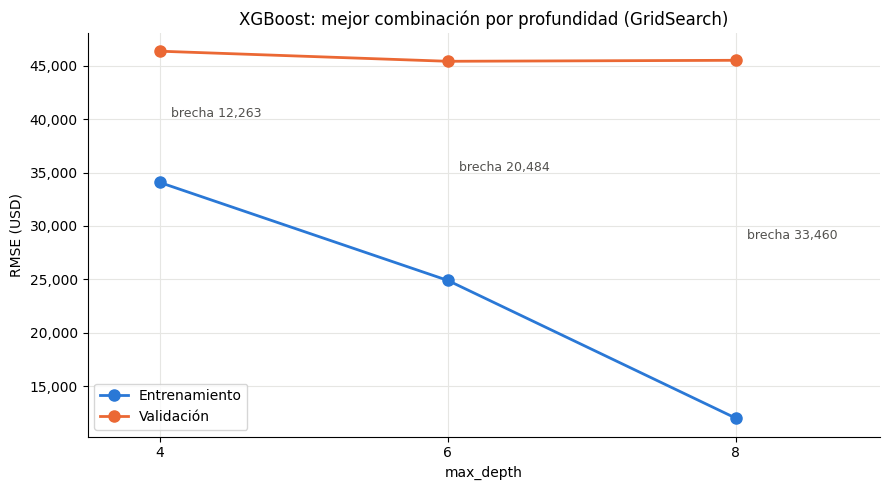

In [48]:
mejor_por_prof = res_grid.loc[res_grid.groupby('param_max_depth')['RMSE val'].idxmin()].sort_values('param_max_depth')
prof = mejor_por_prof['param_max_depth'].astype(int).values

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(prof, mejor_por_prof['RMSE train'], color=AZUL, lw=2, marker='o', ms=8, label='Entrenamiento')
ax.plot(prof, mejor_por_prof['RMSE val'], color=NARANJA, lw=2, marker='o', ms=8, label='Validación')
for x, tr, va in zip(prof, mejor_por_prof['RMSE train'], mejor_por_prof['RMSE val']):
    ax.annotate(f'brecha {va - tr:,.0f}', (x, (tr + va) / 2), textcoords='offset points', xytext=(8, 0), fontsize=9, color=GRIS)
ax.set_xticks(prof)
ax.set_xlim(3.5, 9.0)
ax.set_xlabel('max_depth')
ax.set_ylabel('RMSE (USD)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:,.0f}'))
ax.set_title('XGBoost: mejor combinación por profundidad (GridSearch)')
ax.legend()
fig.tight_layout()
plt.show()

## **6.1. Evaluación final en el 30% de prueba**

Ahora, y solo ahora, se usa el 30% de prueba que se reservó al inicio. Se comparan el XGBoost del parcial y el XGBoost hiperparametrizado, ambos entrenados con el 70% completo. Al evaluarse con datos que no intervinieron en ninguna decisión, este resultado es la estimación honesta del desempeño del modelo con datos nuevos.

In [49]:
def metricas(y_real, y_pred):
    return {'RMSE': np.sqrt(metrics.mean_squared_error(y_real, y_pred)),
            'MAE': metrics.mean_absolute_error(y_real, y_pred),
            'MAPE': metrics.mean_absolute_percentage_error(y_real, y_pred),
            'R²': metrics.r2_score(y_real, y_pred),
            'Error máx.': metrics.max_error(y_real, y_pred)}

modelo_xgb_parcial = xgb.XGBRegressor(**dict(xgb_parcial, n_jobs=-1)).fit(X_entreno_sel, Y_entreno)
modelo_xgb_final = grid.best_estimator_   # GridSearchCV ya lo reentrenó con el 70% completo (refit=True)

evaluacion = {}
for nombre, m in [('XGBoost parcial', modelo_xgb_parcial), ('XGBoost hiperparametrizado', modelo_xgb_final)]:
    evaluacion[(nombre, 'Entrenamiento 70%')] = metricas(Y_entreno, m.predict(X_entreno_sel))
    evaluacion[(nombre, 'Prueba 30%')] = metricas(Y_prueba, m.predict(X_prueba_sel))
evaluacion = pd.DataFrame(evaluacion).T
evaluacion.style.format({'RMSE': '{:,.0f}', 'MAE': '{:,.0f}', 'MAPE': '{:.1%}', 'R²': '{:.3f}', 'Error máx.': '{:,.0f}'})

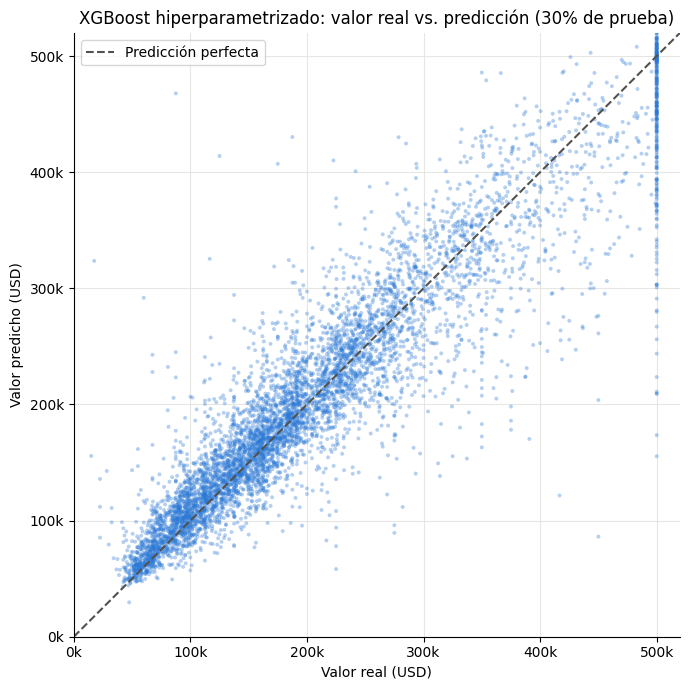

In [50]:
Y_pred_final = modelo_xgb_final.predict(X_prueba_sel)

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(Y_prueba, Y_pred_final, s=8, alpha=0.35, color=AZUL, edgecolors='none')
lim = [0, 520000]
ax.plot(lim, lim, color=GRIS, ls='--', lw=1.5, label='Predicción perfecta')
ax.set_xlim(lim); ax.set_ylim(lim)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v/1000:,.0f}k'))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v/1000:,.0f}k'))
ax.set_xlabel('Valor real (USD)')
ax.set_ylabel('Valor predicho (USD)')
ax.set_title('XGBoost hiperparametrizado: valor real vs. predicción (30% de prueba)')
ax.legend(loc='upper left')
fig.tight_layout()
plt.show()

**Limitación de los datos: el tope de 500.001 dólares.** En la gráfica se ve una columna vertical de puntos en el extremo derecho. Son los distritos cuyo valor real es exactamente 500.001: el censo registró como 500.001 cualquier valor superior, así que el valor verdadero de esas viviendas es desconocido. Para esos registros el modelo no puede acertar, y conviene medir su efecto por separado.

In [51]:
tope = Y_prueba >= 500001
print(f'Registros con el valor topado en prueba: {tope.sum()} de {len(Y_prueba)} ({tope.mean():.1%})')
print(f'MAE en registros topados:   {metrics.mean_absolute_error(Y_prueba[tope], Y_pred_final[tope]):>10,.0f}')
print(f'MAE en el resto:            {metrics.mean_absolute_error(Y_prueba[~tope], Y_pred_final[~tope]):>10,.0f}')

Registros con el valor topado en prueba: 275 de 6192 (4.4%)
MAE en registros topados:       58,659
MAE en el resto:                26,929


## **6.2. Importancia de las variables en el modelo final**

Se usa importancia por permutación sobre el 30% de prueba: cuánto aumenta el RMSE del modelo final cuando se desordena cada variable.

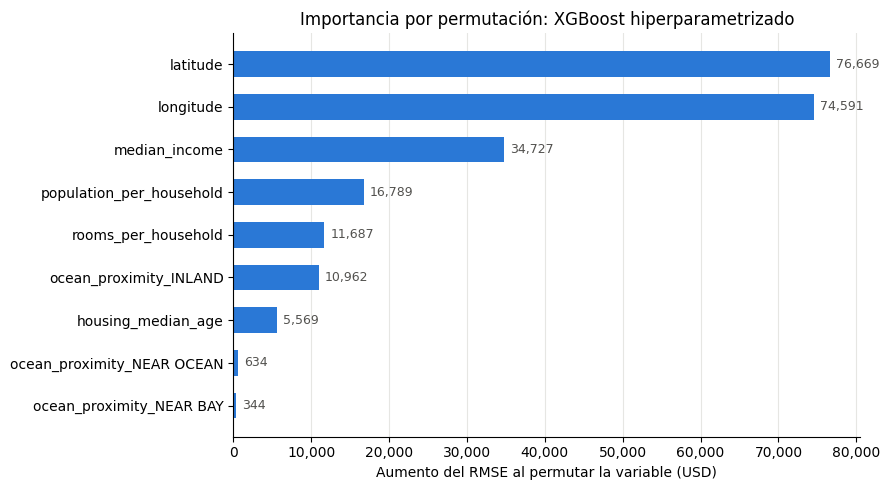

In [52]:
perm_final = permutation_importance(modelo_xgb_final, X_prueba_sel, Y_prueba, n_repeats=5,
                                    scoring='neg_root_mean_squared_error', random_state=SEMILLA, n_jobs=-1)
imp_final = pd.Series(perm_final.importances_mean, index=variables_finales).sort_values()

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(imp_final.index, imp_final.values, color=AZUL, height=0.6)
for i, v in enumerate(imp_final.values):
    ax.text(v + imp_final.max() * 0.01, i, f'{v:,.0f}', va='center', fontsize=9, color=GRIS)
ax.set_xlabel('Aumento del RMSE al permutar la variable (USD)')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:,.0f}'))
ax.set_title('Importancia por permutación: XGBoost hiperparametrizado')
ax.grid(axis='y', visible=False)
fig.tight_layout()
plt.show()

## **6.3. Conclusión de la hiperparametrización**

- **Mejores hiperparámetros:** `max_depth=6`, `learning_rate=0.05`, `n_estimators=600`, `min_child_weight=1`, `subsample=0.8`.
- **Menor error.** El RMSE de validación cruzada bajó de 48.761 a 45.396 dólares (7% menos). En el 30% de prueba, que no se usó en ninguna decisión, el RMSE pasó de 46.553 a 43.577, el MAE de 30.460 a 28.338, el MAPE de 17,2% a 16,0% y el R² de 0,835 a 0,855.
- **La estimación de la validación cruzada fue confiable.** El error en prueba (43.577) es incluso algo menor que el estimado por validación cruzada (45.396), así que el modelo se comporta con datos nuevos como se esperaba.
- **Mucho menos sobreajuste.** El R² de entrenamiento pasó de 1,000 a 0,946 y el RMSE de entrenamiento de 1.391 a 26.941 dólares: el modelo ya no memoriza. Sigue habiendo una brecha frente a prueba (26.941 contra 43.577), algo normal en boosting. En la gráfica por profundidad se ve que pasar de 6 a 8 niveles reduce el error de entrenamiento a la mitad sin mejorar la validación: esa complejidad extra solo agrega sobreajuste, y por eso el mejor modelo usa profundidad 6.
- **Límite de la búsqueda.** Las mejores combinaciones usan `learning_rate=0.05` y 600 árboles, que son los extremos de la grilla. Una tasa menor con más árboles podría mejorar un poco más, pero la ganancia sería marginal: las 10 mejores combinaciones están a menos de 450 dólares entre sí, menos que la variación entre particiones (unos 1.600).
- **Errores grandes por el tope del censo.** El error máximo sigue cerca de 380.000 dólares. En los distritos con el valor topado en 500.001 el MAE es de 58.659 dólares, más del doble que en el resto (26.929), porque su valor real es desconocido.
- **Variables más importantes.** En el modelo final la ubicación es lo más determinante: al desordenar `latitude` o `longitude` el RMSE aumenta unos 75.000 dólares, frente a unos 35.000 al desordenar `median_income`. Esto difiere del Random Forest de la sección 4.2, donde dominaba el ingreso: XGBoost combina mejor las dos coordenadas para ubicar zonas concretas de precio, y desordenar una sola de ellas destruye esa ubicación. Las dummies `NEAR BAY` y `NEAR OCEAN` casi no aportan (menos de 700 dólares), porque su información ya está en las coordenadas.

**Modelo final: XGBoost hiperparametrizado.** Explica el 85,5% de la variabilidad del precio en datos nuevos, con un error típico de unos 28.000 dólares (16% en términos relativos).

En la sección 7 este modelo se reentrena con el 100% de los datos y se guarda para el despliegue.

# **7. Modelo final para el despliegue**

El modelo hiperparametrizado se reentrena con el **100% de los datos** (70% + 30%) usando los mejores hiperparámetros encontrados por GridSearch: una vez evaluado, no hay razón para dejar fuera el 30% de prueba, y con más datos el modelo aprende mejor.

Se guarda en dos archivos que usa la aplicación de despliegue (`Despliegue.ipynb` / `app.py`):

- `modelo_xgb_final.json`: el modelo en el formato nativo de XGBoost. A diferencia de `pickle`, este formato funciona aunque la versión de las librerías cambie entre el entorno de entrenamiento y el de despliegue.
- `modelo_info.json`: la información necesaria para usar el modelo: variables en el orden exacto, hiperparámetros, métricas de prueba, importancia de las variables y rangos de los datos de entrenamiento (para advertir cuando un dato ingresado está fuera de lo que el modelo conoce).

In [53]:
import json

modelo_despliegue = xgb.XGBRegressor(objective='reg:squarederror', colsample_bytree=0.8, tree_method='hist',
                                     random_state=SEMILLA, n_jobs=-1, **grid.best_params_)
modelo_despliegue.fit(X_cand[variables_finales], Y_fs)   # 100% de los datos
modelo_despliegue.save_model('modelo_xgb_final.json')

columnas_crudas = ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms',
                   'population', 'households', 'median_income']
metricas_prueba = evaluacion.loc[('XGBoost hiperparametrizado', 'Prueba 30%')]

info = {
    'variables': variables_finales,
    'hiperparametros': grid.best_params_,
    'metricas_prueba': {k: float(v) for k, v in metricas_prueba.items()},
    'importancia_permutacion': {k: float(v) for k, v in imp_final.sort_values(ascending=False).items()},
    'rangos': {c: [float(data[c].min()), float(data[c].max())] for c in columnas_crudas},
    'rangos_razones': {c: [float(data_fs[c].quantile(0.005)), float(data_fs[c].quantile(0.995))]
                       for c in ['rooms_per_household', 'population_per_household']},
    'tope_censo': 500001,
}
with open('modelo_info.json', 'w', encoding='utf-8') as f:
    json.dump(info, f, ensure_ascii=False, indent=2)

print('Guardados: modelo_xgb_final.json y modelo_info.json')
print('Variables:', variables_finales)
print('Hiperparámetros:', grid.best_params_)

Guardados: modelo_xgb_final.json y modelo_info.json
Variables: ['longitude', 'latitude', 'housing_median_age', 'median_income', 'population_per_household', 'rooms_per_household', 'ocean_proximity_INLAND', 'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN']
Hiperparámetros: {'learning_rate': 0.05, 'max_depth': 6, 'min_child_weight': 1, 'n_estimators': 600, 'subsample': 0.8}


In [54]:
# Comprobación: el modelo guardado se carga y predice igual que el que está en memoria
modelo_cargado = xgb.XGBRegressor()
modelo_cargado.load_model('modelo_xgb_final.json')
muestra = X_cand[variables_finales].head(5)
pd.DataFrame({'En memoria': modelo_despliegue.predict(muestra), 'Cargado del archivo': modelo_cargado.predict(muestra),
              'Valor real': Y_fs.head(5).values}).round(0)

,En memoria,Cargado del archivo,Valor real
0,"430,786.0000","430,786.0000","452,600.0000"
1,"388,530.0000","388,530.0000","358,500.0000"
2,"397,244.0000","397,244.0000","352,100.0000"
3,"337,935.0000","337,935.0000","341,300.0000"
4,"260,957.0000","260,957.0000","342,200.0000"
